<a href="https://colab.research.google.com/github/kothawader8-arch/re-plate/blob/main/part1_setup_data_instrumented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instrumentation (added for reproducibility -- see README_instrumentation.md)

### 0. Run identity -- stamps every artifact with a run ID

In [1]:
import time, platform

RUN_ID = time.strftime("%Y%m%d_%H%M%S")
manifest = {
    "run_id": RUN_ID,
    "started_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "python": platform.python_version(),
}
print(f"RUN_ID = {RUN_ID}")
print("RESULTS_DIR will be pinned to this run right after it is created below.")


RUN_ID = 20260814_133445
RESULTS_DIR will be pinned to this run right after it is created below.


# Lung Cancer Detection from CT Scans : Deep Learning Pipeline

**MSc Dissertation Project
Rushikesh Kothawade, University of Leeds**

This notebook implements the full experimental pipeline described in the dissertation:
5 CNN architectures, a soft-voting ensemble, Grad-CAM explainability, and
Monte Carlo Dropout uncertainty quantification, evaluated on the primary
Chest CT-Scan Images dataset and validated on the independent IQ-OTH/NCCD dataset.

**Notebook structure (this is Part 1 of the full pipeline):**
1. Environment setup
2. Data acquisition (Kaggle datasets)
3. Exploratory Data Analysis (EDA)
4. Preprocessing pipeline: resizing, normalisation, augmentation
5. SMOTE utility for class imbalance (applied later, in the cross-dataset chapter)

> Later parts (to follow) will cover: model architectures, training loops,
> ensemble construction, Grad-CAM, MC Dropout, and cross-dataset validation.

**Runtime:** Set `Runtime > Change runtime type > GPU` (T4 is sufficient) before running.




## 1. Environment Setup

In [2]:
!pip install -q imbalanced-learn kaggle

In [3]:
import os
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # trades some speed for reproducibility

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU.")

Using device: cuda
GPU: Tesla T4


In [4]:
# Project directory structure (all paths relative to Colab's working dir,
# or point PROJECT_ROOT at a Google Drive folder if you want persistence
# across sessions).

from pathlib import Path

USE_DRIVE = True  # Colab wipes /content on disconnect; for a multi-hour training
                   # run, losing checkpoints is worse than the extra Drive-mount step.
                   # Set False if you just want a quick, throwaway test run.

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/lung_cancer_project')
else:
    PROJECT_ROOT = Path('/content/lung_cancer_project')

DATA_DIR = PROJECT_ROOT / 'data'
PRIMARY_DIR = DATA_DIR / 'chest_ctscan'
SECONDARY_DIR = DATA_DIR / 'iqoth_nccd'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'

for d in [DATA_DIR, PRIMARY_DIR, SECONDARY_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/lung_cancer_project


### 0b. Pin RESULTS_DIR to this run

In [5]:
# Pin RESULTS_DIR to this specific run so artifacts from different
# executions never land in the same folder and get overwritten/confused.
RESULTS_DIR = RESULTS_DIR / RUN_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(exist_ok=True)
(RESULTS_DIR / "tables").mkdir(exist_ok=True)
manifest["results_dir"] = str(RESULTS_DIR)
print(f"RESULTS_DIR pinned to: {RESULTS_DIR}")


RESULTS_DIR pinned to: /content/drive/MyDrive/lung_cancer_project/results/20260814_133445


### 1. Library + hardware versions

In [6]:
import torch, torchvision, sklearn
manifest["versions"] = {
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "sklearn": sklearn.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
print(manifest["versions"])


{'torch': '2.11.0+cu128', 'torchvision': '0.26.0+cu128', 'sklearn': '1.6.1', 'cuda_available': True, 'gpu_name': 'Tesla T4'}


## 2. Data Acquisition

Both datasets are pulled from Kaggle. You'll need a Kaggle API token
(`kaggle.json`) — get one from **Kaggle > Account > Create New API Token**,
then upload it when prompted below.

* **Primary dataset:** Chest CT-Scan Images (Hanny, 2020) — 4-class, used for
  all training/validation/testing.
* **Secondary dataset:** IQ-OTH/NCCD Lung Cancer Dataset (Hamdalla F. Al-Yasriy,2020) — 3-class, used *only* for cross-dataset generalisation testing later.

**Verify the secondary dataset slug yourself** — there are multiple re-uploads
of this dataset on Kaggle under different slugs, and the one below is not
guaranteed to be the exact version cited in the dissertation.

In [7]:
from google.colab import files

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
kaggle_json_path = kaggle_dir / 'kaggle.json'

if not kaggle_json_path.exists():
    print("Upload your kaggle.json API token:")
    uploaded = files.upload()
    with open(kaggle_json_path, 'wb') as f:
        f.write(list(uploaded.values())[0])
    os.chmod(kaggle_json_path, 0o600)
    print("kaggle.json saved.")
else:
    print("kaggle.json already present.")

Upload your kaggle.json API token:


Saving kaggle.json.txt to kaggle.json.txt
kaggle.json saved.


In [8]:
import subprocess

# Download and unpack the primary dataset (Chest CT-Scan Images).
# Failure now raises instead of silently leaving PRIMARY_DIR in a bad state.
if not any(PRIMARY_DIR.iterdir()):
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "mohamedhanyyy/chest-ctscan-images",
         "-p", str(PRIMARY_DIR), "--unzip"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"Kaggle download failed:\n{result.stderr}")
    print("Primary dataset downloaded.")
else:
    print("Primary dataset already present, skipping download.")

# Quick sanity check of the folder structure
for p in sorted(PRIMARY_DIR.rglob('*'))[:20]:
    print(p.relative_to(PRIMARY_DIR))

Primary dataset already present, skipping download.
Data
Data/test
Data/test/adenocarcinoma
Data/test/adenocarcinoma/000108 (3).png
Data/test/adenocarcinoma/000109 (2).png
Data/test/adenocarcinoma/000109 (4).png
Data/test/adenocarcinoma/000109 (5).png
Data/test/adenocarcinoma/000112 (2).png
Data/test/adenocarcinoma/000113 (7).png
Data/test/adenocarcinoma/000114 (5).png
Data/test/adenocarcinoma/000114.png
Data/test/adenocarcinoma/000115 (4).png
Data/test/adenocarcinoma/000115 (8).png
Data/test/adenocarcinoma/000115.png
Data/test/adenocarcinoma/000116 (5).png
Data/test/adenocarcinoma/000116 (7).png
Data/test/adenocarcinoma/000116 (9).png
Data/test/adenocarcinoma/000117 (4).png
Data/test/adenocarcinoma/000117 (8).png
Data/test/adenocarcinoma/000117.png


In [9]:
# Download and unpack the secondary dataset (IQ-OTH/NCCD).
# NOTE: confirm this Kaggle slug matches the dataset version you cite —
# there are multiple re-uploads under different slugs.
if not any(SECONDARY_DIR.iterdir()):
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "hamdallak/the-iqothnccd-lung-cancer-dataset",
         "-p", str(SECONDARY_DIR), "--unzip"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"Kaggle download failed:\n{result.stderr}")
    print("Secondary dataset downloaded.")
else:
    print("Secondary dataset already present, skipping download.")

for p in sorted(SECONDARY_DIR.rglob('*'))[:20]:
    print(p.relative_to(SECONDARY_DIR))

Secondary dataset already present, skipping download.
Test cases
Test cases/000001_03_01_088.png
Test cases/000017_02_01_016.png
Test cases/000019_01_01_021.png
Test cases/000019_02_01_025.png
Test cases/000019_03_01_025.png
Test cases/000020_01_01_066.png
Test cases/000020_02_01_062.png
Test cases/000020_03_01_134.png
Test cases/000020_03_01_166.png
Test cases/000020_03_01_212.png
Test cases/000020_04_01_116.png
Test cases/000020_04_01_143.png
Test cases/000020_04_01_159.png
Test cases/000021_01_01_016.png
Test cases/000021_02_01_068.png
Test cases/000021_03_01_012.png
Test cases/000021_03_01_017.png
Test cases/000021_04_01_090.png
Test cases/000027_01_01_113.png


In [10]:
from pathlib import Path

def find_class_root(base_dir, required_subdirs):
    """
    Searches base_dir recursively to find the folder that directly contains
    the expected class subdirectories (e.g., 'normal', 'malignant').
    Raises if nothing matches, instead of silently falling back to base_dir.
    """
    base_dir = Path(base_dir)
    required_set = {s.lower() for s in required_subdirs}

    for path in base_dir.rglob('*'):
        if path.is_dir():
            subdirs = {p.name.lower() for p in path.iterdir() if p.is_dir()}
            if required_set.issubset(subdirs):
                return path

    raise FileNotFoundError(
        f"Could not find a folder under {base_dir} containing subdirs {required_subdirs}. "
        f"The archive layout may have changed — inspect {base_dir} manually."
    )

In [11]:
def find_class_root(base_dir, required_subdirs):
    """
    Searches base_dir recursively to find the folder that directly contains
    subdirectories matching each of required_subdirs (substring match, so
    'normal' matches 'Normal cases', 'malignant' matches 'Malignant cases', etc.)
    """
    base_dir = Path(base_dir)
    required_set = {s.lower() for s in required_subdirs}

    for path in base_dir.rglob('*'):
        if path.is_dir():
            subdirs = [p.name.lower() for p in path.iterdir() if p.is_dir()]
            if all(any(req in sd for sd in subdirs) for req in required_set):
                return path

    raise FileNotFoundError(
        f"Could not find a folder under {base_dir} containing subdirs matching {required_subdirs}. "
        f"The archive layout may have changed — inspect {base_dir} manually. "
        f"Directory tree:\n" + "\n".join(str(p) for p in sorted(base_dir.rglob('*')) if p.is_dir())
    )

## 3. Exploratory Data Analysis (EDA)

Reproduces the statistics reported in Section 3.1.4: mean pixel intensity,
per-class image entropy, and a PCA variance check.

**Fixed:** these statistics are now computed on the training split only.
Previously `list_images_by_class` pooled train+valid+test together while the
resulting figure was labelled "Training Set Sample" — a mismatch between what
was computed and what was reported.

In [12]:
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

def list_images_by_class(root, limit_per_class=None, split_only=None):
    """Returns {class_name: [image_paths]} for a class-folder dataset root.
    If split_only is given (e.g. 'train'), only that split's images are used.
    Otherwise, if the root has train/val/test subfolders, images from all of
    them are pooled together."""
    root = Path(root)
    images_by_class = defaultdict(list)

    split_names = {'train', 'valid', 'val', 'test'}
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    has_splits = any(d.name.lower() in split_names for d in subdirs)

    if has_splits and split_only:
        search_dirs = [d for d in subdirs if d.name.lower() == split_only]
    elif has_splits:
        search_dirs = subdirs
    else:
        search_dirs = [root]

    for sd in search_dirs:
        class_dirs = [d for d in sd.iterdir() if d.is_dir()] if sd.is_dir() else []
        for cd in class_dirs:
            imgs = list(cd.glob('*.png')) + list(cd.glob('*.jpg')) + list(cd.glob('*.jpeg'))
            images_by_class[cd.name].extend(imgs)

    if limit_per_class:
        images_by_class = {k: v[:limit_per_class] for k, v in images_by_class.items()}
    return dict(images_by_class)

# Scoped to the training split so the label matches what's actually computed.
primary_train_images = list_images_by_class(PRIMARY_DIR / 'Data', split_only='train')
for cls, imgs in primary_train_images.items():
    print(f"{cls}: {len(imgs)} images")

adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 images
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 images
normal: 148 images
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 images


In [14]:
def image_entropy(img_gray):
    """Shannon entropy (bits) of an 8-bit grayscale image's intensity histogram."""
    hist, _ = np.histogram(img_gray.flatten(), bins=256, range=(0, 256))
    prob = hist / (hist.sum() + 1e-12)
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())

def compute_intensity_and_entropy(images_by_class, sample_size=200):
    rows = []
    for cls, paths in images_by_class.items():
        sample = random.sample(paths, min(sample_size, len(paths)))
        for p in sample:
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            rows.append({
                'class': cls,
                'mean_intensity': img.mean() / 255.0,
                'entropy': image_entropy(img),
            })
    import pandas as pd
    return pd.DataFrame(rows)

eda_df = compute_intensity_and_entropy(primary_train_images, sample_size=200)
print(eda_df.groupby('class')[['mean_intensity', 'entropy']].agg(['mean', 'std']))

                                                 mean_intensity            \
                                                           mean       std   
class                                                                       
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib             0.323912  0.099078   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa          0.244981  0.071965   
normal                                                 0.446603  0.150342   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.261638  0.073352   

                                                   entropy            
                                                      mean       std  
class                                                                 
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib        6.393681  0.323903  
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa     6.082682  0.450881  
normal                                            6.314157  0.908086  
squamous.cell.carcinoma_left.hilum

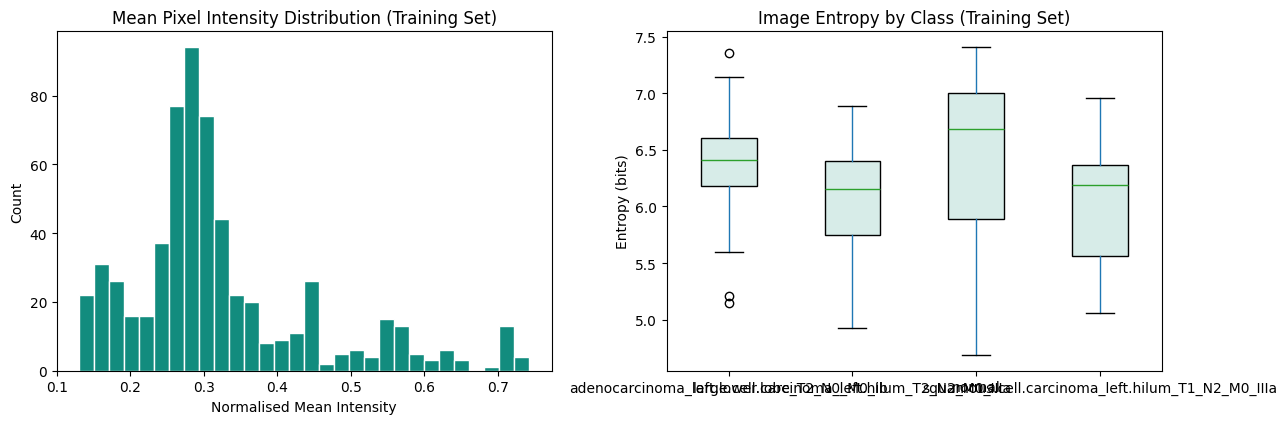


Interpretation check: cancer subtypes should show higher mean entropy
than Normal cases (more textural complexity) — confirms the dataset
carries a learnable visual signal before any model is trained.


In [15]:
# Visualise: mean intensity distribution and per-class entropy (training set)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(eda_df['mean_intensity'], bins=30, color='#128C7E', edgecolor='white')
axes[0].set_title('Mean Pixel Intensity Distribution (Training Set)')
axes[0].set_xlabel('Normalised Mean Intensity')
axes[0].set_ylabel('Count')

eda_df.boxplot(column='entropy', by='class', ax=axes[1], grid=False,
                patch_artist=True,
                boxprops=dict(facecolor='#D7ECE8'))
axes[1].set_title('Image Entropy by Class (Training Set)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Entropy (bits)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_intensity_entropy.png', dpi=150)
plt.show()

print("\nInterpretation check: cancer subtypes should show higher mean entropy")
print("than Normal cases (more textural complexity) — confirms the dataset")
print("carries a learnable visual signal before any model is trained.")

In [16]:
# PCA on flattened, downsampled images — checks how much variance is
# captured by a low-dimensional linear projection (Section 3.1.4).
# Caveat: 64x64 grayscale PCA variance is a weak proxy for what a 224x224 RGB
# CNN with augmentation will actually learn — treat this as a rough prior
# check, not evidence of class separability, when writing this up.
from sklearn.decomposition import PCA
import pandas as pd

def load_flattened(images_by_class, size=(64, 64), sample_size=150):
    X, y = [], []
    for cls, paths in images_by_class.items():
        sample = random.sample(paths, min(sample_size, len(paths)))
        for p in sample:
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, size)
            X.append(img.flatten() / 255.0)
            y.append(cls)
    return np.array(X), np.array(y)

X_flat, y_flat = load_flattened(primary_train_images)
pca = PCA(n_components=50, random_state=SEED)
pca.fit(X_flat)
explained = pca.explained_variance_ratio_.sum()
print(f"First 50 principal components explain {explained*100:.1f}% of variance")

# Within-class variance check
X_pca = pca.transform(X_flat)
var_by_class = pd.DataFrame(X_pca, index=y_flat).groupby(level=0).var().mean(axis=1)
print("\nMean within-class variance (top-50 PCA space):")
print(var_by_class.sort_values(ascending=False))

First 50 principal components explain 89.0% of variance

Mean within-class variance (top-50 PCA space):
normal                                              7.173397
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib          2.144840
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       1.615838
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa    1.492821
dtype: float64


## 4. Preprocessing Pipeline

Implements Section 3.2.1: resize to 224x224, ImageNet normalisation,
and the augmentation policy applied to the **training split only**
(mild geometric perturbations, no aggressive warping — CT geometry is
standardised, so only clinically plausible variation is simulated).

Note on `ColorJitter`: CT images don't vary in "colour" the way natural
photos do. If challenged on this in the dissertation, frame it as a proxy
for scanner/windowing-level intensity variation rather than colour variation —
that's the closer real-world analogue.

In [17]:
from torchvision import transforms

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))], p=0.3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation / test: deterministic, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:", train_transform)
print("\nEval transform:", eval_transform)

Train transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    RandomApply(
    p=0.3
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.5))
)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [18]:
print("Contents of PRIMARY_DIR:")
for path in Path(PRIMARY_DIR).iterdir():
    print("  -", path.name)

Contents of PRIMARY_DIR:
  - Data


In [19]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Define direct paths to each split folder
dataset_root = PRIMARY_DIR / 'Data'
train_dir = dataset_root / "train"
valid_dir = dataset_root / "valid"
test_dir  = dataset_root / "test"

# Load datasets with their respective transforms
train_dataset = ImageFolder(train_dir, transform=train_transform)
valid_dataset = ImageFolder(valid_dir, transform=eval_transform)
test_dataset  = ImageFolder(test_dir,  transform=eval_transform)

# Extract class names and count from the training dataset as the canonical source
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

# Ensure class mappings are consistent across all splits.
# ImageFolder infers class_to_idx from folder names, which can differ if names aren't identical.
# We explicitly set them to match the train_dataset's mapping.
valid_dataset.class_to_idx = train_dataset.class_to_idx
valid_dataset.classes = train_dataset.classes
test_dataset.class_to_idx = train_dataset.class_to_idx
test_dataset.classes = train_dataset.classes

# Fixed: previously nothing verified label indices line up across splits.
# If a split's class-folder names differ even slightly, ImageFolder assigns
# indices independently per split, silently corrupting every downstream
# confusion matrix, Grad-CAM class target, and metric.
assert valid_dataset.classes == CLASS_NAMES, (
    f"Class mismatch: valid has {valid_dataset.classes}, train has {CLASS_NAMES}"
)
assert test_dataset.classes == CLASS_NAMES, (
    f"Class mismatch: test has {test_dataset.classes}, train has {CLASS_NAMES}"
)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

Classes (4): ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Train: 613 | Valid: 72 | Test: 315


In [20]:
def log_class_counts(name, class_counts_dict):
    manifest.setdefault("dataset_counts", {})[name] = class_counts_dict
    print(f"{name}: {class_counts_dict}")
    return class_counts_dict


_primary_train_counts = {
    c: sum(1 for _, y in train_dataset.samples if y == train_dataset.class_to_idx[c])
    for c in train_dataset.classes
}

log_class_counts("primary_train", _primary_train_counts)

log_class_counts(
    "primary_valid",
    {
        c: sum(1 for _, y in valid_dataset.samples if y == valid_dataset.class_to_idx[c])
        for c in valid_dataset.classes
    }
)

log_class_counts(
    "primary_test",
    {
        c: sum(1 for _, y in test_dataset.samples if y == test_dataset.class_to_idx[c])
        for c in test_dataset.classes
    }
)

primary_train: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115, 'normal': 148, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155}
primary_valid: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21, 'normal': 13, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15}
primary_test: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51, 'normal': 54, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90}


{'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120,
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51,
 'normal': 54,
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90}

### 2. Primary dataset class counts

In [21]:
def log_class_counts(name, class_counts_dict):
    manifest.setdefault("dataset_counts", {})[name] = class_counts_dict
    print(f"{name}: {class_counts_dict}")
    return class_counts_dict

_primary_train_counts = {
    c: sum(1 for _, y in train_dataset.samples if y == train_dataset.class_to_idx[c])
    for c in train_dataset.classes
}
log_class_counts("primary_train", _primary_train_counts)
log_class_counts("primary_valid", {c: sum(1 for _, y in valid_dataset.samples if y == valid_dataset.class_to_idx[c]) for c in valid_dataset.classes})
log_class_counts("primary_test", {c: sum(1 for _, y in test_dataset.samples if y == test_dataset.class_to_idx[c]) for c in test_dataset.classes})


primary_train: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115, 'normal': 148, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155}
primary_valid: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21, 'normal': 13, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15}
primary_test: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51, 'normal': 54, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90}


{'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120,
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51,
 'normal': 54,
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90}

In [22]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check: pull one batch and confirm shapes
xb, yb = next(iter(train_loader))
print(f"Batch images: {xb.shape}  (expect [B, 3, {IMG_SIZE}, {IMG_SIZE}])")
print(f"Batch labels: {yb.shape}, unique labels in batch: {yb.unique().tolist()}")

Batch images: torch.Size([32, 3, 224, 224])  (expect [B, 3, 224, 224])
Batch labels: torch.Size([32]), unique labels in batch: [0, 1, 2, 3]


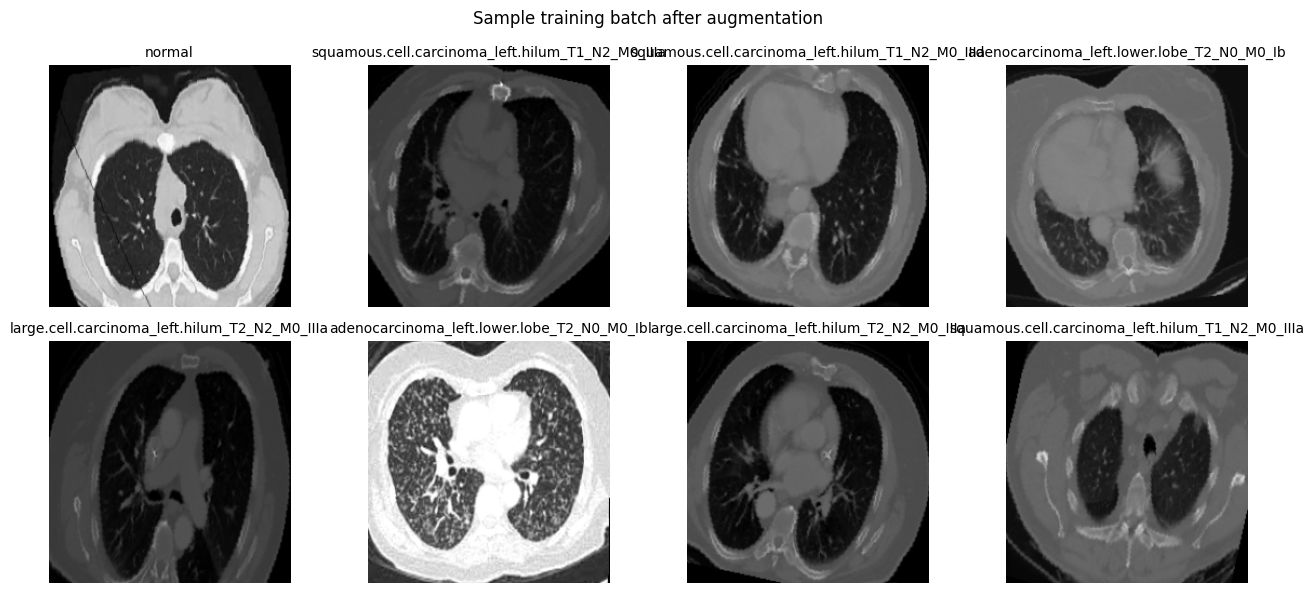

In [23]:
# Visualise a batch after augmentation, to sanity-check the pipeline visually
def denormalise(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    img = denormalise(xb[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[yb[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample training batch after augmentation')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_augmented_batch.png', dpi=150)
plt.show()

## 5. SMOTE Utility (defined here, applied later)

Used only in the cross-dataset generalisation chapter, on the smaller/imbalanced
secondary dataset. **Limitation to acknowledge in the dissertation:** this runs
SMOTE on flattened raw pixels (224x224x3 ≈ 150k dimensions). Interpolating
between raw pixel vectors produces blurry, unrealistic synthetic images compared
to feature-space or generative augmentation — it's a defensible baseline, not a
strong method, and reviewers may push on this.

In [24]:
from imblearn.over_sampling import SMOTE

def apply_smote_to_image_folder(images_by_class, size=(224, 224), k_neighbors=5):
    """Flattens images and applies SMOTE to balance classes.
    Returns synthetic flattened vectors + labels, NOT images ready for a CNN —
    caller must reshape back to (H, W, C) before any further use."""
    X, y = [], []
    for cls, paths in images_by_class.items():
        for p in paths:
            img = cv2.imread(str(p))
            if img is None:
                continue
            img = cv2.resize(img, size)
            X.append(img.flatten() / 255.0)
            y.append(cls)
    X = np.array(X)
    y = np.array(y)

    smote = SMOTE(k_neighbors=k_neighbors, random_state=SEED)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return X_resampled, y_resampled

In [25]:
import copy
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

set_seed(SEED)

In [26]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()
        channels = [3, 16, 32, 64, 128, 256]
        blocks = []
        for i in range(len(channels) - 1):
            blocks.append(nn.Sequential(
                nn.Conv2d(channels[i], channels[i + 1], kernel_size=3, padding=1),
                nn.BatchNorm2d(channels[i + 1]),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            ))
        self.features = nn.Sequential(*blocks)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        return self.classifier(x)


def build_custom_cnn(num_classes=NUM_CLASSES, dropout=0.5):
    model = CustomCNN(num_classes=num_classes, dropout=dropout)
    return model

# Quick shape check
_test_model = build_custom_cnn()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"CustomCNN output shape: {_test_out.shape}  (expect [2, {NUM_CLASSES}])")
del _test_model, _test_out

CustomCNN output shape: torch.Size([2, 4])  (expect [2, 4])


In [27]:
def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights='DEFAULT')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

_test_model = build_resnet50()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"ResNet-50 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


ResNet-50 output shape: torch.Size([2, 4])


In [28]:
def build_vgg16(num_classes=NUM_CLASSES, dropout=0.5):
    model = models.vgg16(weights='DEFAULT')
    # model.classifier is:
    # [0] Linear(25088,4096) [1] ReLU [2] Dropout
    # [3] Linear(4096,4096)  [4] ReLU [5] Dropout
    # [6] Linear(4096,1000)
    # Keep [0:5] (up to the second ReLU, output=4096), replace the rest.
    kept = model.classifier[:5]  # Linear->ReLU->Dropout->Linear->ReLU (output 4096)
    new_head = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(1024, num_classes),
    )
    model.classifier = nn.Sequential(*kept, new_head)
    return model

_test_model = build_vgg16()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"VGG-16 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 83.1MB/s]


VGG-16 output shape: torch.Size([2, 4])


In [29]:
def build_densenet121(num_classes=NUM_CLASSES):
    model = models.densenet121(weights='DEFAULT')
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

_test_model = build_densenet121()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"DenseNet-121 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 187MB/s]


DenseNet-121 output shape: torch.Size([2, 4])


In [30]:
def build_efficientnet_b3(num_classes=NUM_CLASSES, dropout=0.3):
    model = models.efficientnet_b3(weights='DEFAULT')
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

_test_model = build_efficientnet_b3()
_test_out = _test_model(torch.randn(2, 3, 300, 300))
print(f"EfficientNet-B3 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 133MB/s]


EfficientNet-B3 output shape: torch.Size([2, 4])


In [31]:
MODEL_REGISTRY = {
    'custom_cnn': {
        'build_fn': lambda: build_custom_cnn(dropout=0.50),
        'optimizer': 'adam',
        'lr': 1e-3,
        'scheduler': 'step',
        'scheduler_kwargs': {'step_size': 10, 'gamma': 0.1},
        'batch_size': 32,
        'input_size': 224,
        'weight_decay': 0.0,
        'loss': 'ce',
        'two_phase': False,
        'head_attr': None,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'resnet50': {
        'build_fn': build_resnet50,
        'optimizer': 'adamw',
        'lr': 1e-4,
        'scheduler': 'cosine',
        'scheduler_kwargs': {},
        'batch_size': 32,
        'input_size': 224,
        'weight_decay': 1e-4,
        'loss': 'ce',
        'two_phase': True,
        'head_attr': 'fc',
        'phase1_epochs': 5,
        'phase2_lr': 1e-5,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'vgg16': {
        'build_fn': lambda: build_vgg16(dropout=0.50),
        'optimizer': 'sgd',
        'lr': 1e-3,
        'scheduler': 'plateau',
        'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 3},
        'batch_size': 16,
        'input_size': 224,
        'weight_decay': 5e-4,
        'loss': 'ce',
        'two_phase': False,
        'head_attr': None,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'densenet121': {
        'build_fn': build_densenet121,
        'optimizer': 'adamw',
        'lr': 1e-4,
        'scheduler': 'cosine',
        'scheduler_kwargs': {},
        'batch_size': 32,
        'input_size': 224,
        'weight_decay': 1e-4,
        'loss': 'ce',
        'two_phase': True,
        'head_attr': 'classifier',
        'phase1_epochs': 5,
        'phase2_lr': 1e-5,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'efficientnet_b3': {
        'build_fn': lambda: build_efficientnet_b3(dropout=0.30),
        'optimizer': 'adamw',
        'lr': 1e-4,
        'scheduler': 'cosine',
        'scheduler_kwargs': {},
        'batch_size': 32,
        'input_size': 300,
        'weight_decay': 1e-4,
        'loss': 'label_smooth',
        'loss_kwargs': {'label_smoothing': 0.1},
        'two_phase': False,
        'head_attr': None,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
}

print("Registered models:", list(MODEL_REGISTRY.keys()))

Registered models: ['custom_cnn', 'resnet50', 'vgg16', 'densenet121', 'efficientnet_b3']


### 3. Parameter counts per architecture

In [32]:
def log_param_count(name, model):
    n_total = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    manifest.setdefault("param_counts", {})[name] = {
        "total": n_total, "trainable": n_trainable
    }
    print(f"{name}: {n_total:,} total params, {n_trainable:,} trainable")
    return n_total

for _name in ['custom_cnn', 'resnet50', 'vgg16', 'densenet121', 'efficientnet_b3']:
    _model = MODEL_REGISTRY[_name]['build_fn']()
    log_param_count(_name, _model)
    del _model


custom_cnn: 410,308 total params, 410,308 trainable
resnet50: 23,516,228 total params, 23,516,228 trainable
vgg16: 138,459,972 total params, 138,459,972 trainable
densenet121: 6,957,956 total params, 6,957,956 trainable
efficientnet_b3: 10,702,380 total params, 10,702,380 trainable


In [33]:
def build_dataloaders(input_size, batch_size, num_workers=2):
    """Builds train/valid/test DataLoaders at a given resolution and batch
    size, reusing the split directories resolved in Part 1."""
    train_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))], p=0.3),
        transforms.RandomResizedCrop(input_size, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    train_ds = ImageFolder(train_dir, transform=train_tf)
    valid_ds = ImageFolder(valid_dir, transform=eval_tf)
    test_ds = ImageFolder(test_dir, transform=eval_tf)

    loaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=True),
        'valid': DataLoader(valid_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True),
    }
    return loaders, train_ds.classes

In [34]:
def get_optimizer(name, params, lr, weight_decay):
    name = name.lower()
    if name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == 'adamw':
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif name == 'sgd':
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def get_scheduler(name, optimizer, max_epochs, kwargs):
    name = name.lower()
    if name == 'step':
        return optim.lr_scheduler.StepLR(optimizer, **kwargs)
    elif name == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    elif name == 'plateau':
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, **kwargs)
    raise ValueError(f"Unknown scheduler: {name}")


def get_loss_fn(name, kwargs=None):
    kwargs = kwargs or {}
    name = name.lower()
    if name == 'ce':
        return nn.CrossEntropyLoss()
    elif name == 'label_smooth':
        return nn.CrossEntropyLoss(**kwargs)
    raise ValueError(f"Unknown loss: {name}")


def set_backbone_trainable(model, head_attr, trainable):
    """Freezes/unfreezes every parameter NOT belonging to `head_attr`."""
    head_module = getattr(model, head_attr)
    head_param_ids = {id(p) for p in head_module.parameters()}
    for p in model.parameters():
        if id(p) not in head_param_ids:
            p.requires_grad = trainable

In [35]:
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over `loader`. If optimizer is given, trains; else evaluates."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1

In [36]:
def train_model(model_name, config, checkpoint_dir=CHECKPOINT_DIR, verbose=True):
    """Full training routine for one registered model. Returns the best
    model (by validation loss) and a history dict for plotting."""
    set_seed(SEED)

    loaders, classes = build_dataloaders(config['input_size'], config['batch_size'])
    model = config['build_fn']().to(DEVICE)
    criterion = get_loss_fn(config['loss'], config.get('loss_kwargs'))

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    patience = config['early_stopping_patience']

    def run_training_phase(phase_lr, phase_epochs, phase_label):
        nonlocal best_val_loss, best_state, epochs_no_improve
        optimizer = get_optimizer(config['optimizer'],
                                   filter(lambda p: p.requires_grad, model.parameters()),
                                   phase_lr, config['weight_decay'])
        scheduler = get_scheduler(config['scheduler'], optimizer,
                                   phase_epochs, config['scheduler_kwargs'])

        for epoch in range(phase_epochs):
            t0 = time.time()
            train_loss, train_acc, train_f1 = run_epoch(model, loaders['train'], criterion, optimizer)
            val_loss, val_acc, val_f1 = run_epoch(model, loaders['valid'], criterion, optimizer=None)

            if config['scheduler'] == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)

            improved = val_loss < best_val_loss
            if improved:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if verbose:
                dt = time.time() - t0
                flag = ' *' if improved else ''
                print(f"[{model_name}][{phase_label}] epoch {epoch+1}/{phase_epochs} "
                      f"({dt:.1f}s) train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                      f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}{flag}")

            if epochs_no_improve >= patience:
                if verbose:
                    print(f"[{model_name}] Early stopping ({phase_label}, patience={patience}).")
                return True  # stopped early
        return False

    if config.get('two_phase', False):
        # Phase 1: head only
        set_backbone_trainable(model, config['head_attr'], trainable=False)
        run_training_phase(config['lr'], config['phase1_epochs'], phase_label='phase1-head')

        # Phase 2: full fine-tune at low LR
        set_backbone_trainable(model, config['head_attr'], trainable=True)
        remaining_epochs = config['max_epochs'] - config['phase1_epochs']
        run_training_phase(config['phase2_lr'], remaining_epochs, phase_label='phase2-full')
    else:
        run_training_phase(config['lr'], config['max_epochs'], phase_label='train')

    model.load_state_dict(best_state)

    ckpt_path = Path(checkpoint_dir) / f"{model_name}_best.pt"
    torch.save({
        'model_name': model_name,
        'state_dict': best_state,
        'class_names': classes,          # fixed: was missing — needed to reload
                                          # checkpoints correctly in a fresh runtime
        'config': {k: v for k, v in config.items() if k != 'build_fn'},
    }, ckpt_path)
    if verbose:
        print(f"[{model_name}] Best val_loss={best_val_loss:.4f} — saved to {ckpt_path}")

    return model, history, loaders

### 4/5. Timed training + best-epoch logging wrapper

Use `timed_train(name, ...)` in place of direct `train_model(...)` calls below, to log per-epoch timing and best-validation-loss epoch for every architecture.

In [37]:
def timed_train(name, *args, **kwargs):
    """Wraps train_model(...) with timing + best-epoch logging.
    Use in place of calling train_model(...) directly:
        history = timed_train('resnet50', 'resnet50', MODEL_REGISTRY['resnet50'])
    """
    t0 = time.time()
    history = train_model(*args, **kwargs)
    elapsed = time.time() - t0
    n_epochs = len(history.get('train_loss', history.get('val_loss', [])))
    manifest.setdefault("timing", {})[name] = {
        "total_seconds": elapsed,
        "epochs_run": n_epochs,
        "seconds_per_epoch": elapsed / max(n_epochs, 1),
    }
    print(f"{name}: {elapsed / max(n_epochs,1):.1f} s/epoch over {n_epochs} epochs")

    if 'val_loss' in history and len(history['val_loss']) > 0:
        import numpy as np
        best_epoch = int(np.argmin(history['val_loss'])) + 1
        best_val_loss = float(np.min(history['val_loss']))
        manifest.setdefault("convergence", {})[name] = {
            "best_epoch": best_epoch, "best_val_loss": best_val_loss
        }
        print(f"{name}: best val_loss={best_val_loss:.4f} at epoch {best_epoch}")
    return history

# NOTE: go back to the training loop cell(s) below (where train_model(...) is
# actually called for each of the five architectures) and wrap each call as:
#   history = timed_train(model_name, model_name, MODEL_REGISTRY[model_name])
# matching whatever positional/keyword args train_model actually takes.


In [38]:
from pathlib import Path

trained_models = {}
training_histories = {}
model_loaders = {}

for model_name, config in MODEL_REGISTRY.items():
    print(f"\n{'='*70}\nTraining: {model_name}\n{'='*70}")
    model, history, loaders = train_model(model_name, config)
    trained_models[model_name] = model
    training_histories[model_name] = history
    model_loaders[model_name] = loaders

    # Free GPU memory between models
    torch.cuda.empty_cache()

print("\nAll models trained.")


Training: custom_cnn
[custom_cnn][train] epoch 1/50 (28.5s) train_loss=1.1538 val_loss=1.3620 val_acc=0.2083 val_f1=0.0938 *
[custom_cnn][train] epoch 2/50 (8.2s) train_loss=1.0806 val_loss=0.9978 val_acc=0.4861 val_f1=0.4107 *
[custom_cnn][train] epoch 3/50 (8.0s) train_loss=1.0546 val_loss=0.9439 val_acc=0.5694 val_f1=0.5156 *
[custom_cnn][train] epoch 4/50 (7.8s) train_loss=1.0118 val_loss=0.9240 val_acc=0.4861 val_f1=0.4599 *
[custom_cnn][train] epoch 5/50 (9.0s) train_loss=0.9930 val_loss=1.0034 val_acc=0.4861 val_f1=0.4107
[custom_cnn][train] epoch 6/50 (6.9s) train_loss=0.9847 val_loss=0.9820 val_acc=0.4722 val_f1=0.4062
[custom_cnn][train] epoch 7/50 (9.1s) train_loss=0.9688 val_loss=0.9570 val_acc=0.5278 val_f1=0.4971
[custom_cnn][train] epoch 8/50 (9.3s) train_loss=0.9166 val_loss=1.0387 val_acc=0.4861 val_f1=0.4123
[custom_cnn][train] epoch 9/50 (8.6s) train_loss=0.9718 val_loss=1.1547 val_acc=0.5139 val_f1=0.3877
[custom_cnn][train] epoch 10/50 (8.4s) train_loss=0.9675 val

In [39]:
# Evaluate every trained model on the held-out test set and persist results,
# so Part 3 doesn't silently assume test_loader survives in memory.
test_results = {}
for model_name, model in trained_models.items():
    loaders = model_loaders[model_name]
    criterion = get_loss_fn(MODEL_REGISTRY[model_name]['loss'],
                             MODEL_REGISTRY[model_name].get('loss_kwargs'))
    test_loss, test_acc, test_f1 = run_epoch(model, loaders['test'], criterion, optimizer=None)
    test_results[model_name] = {'test_loss': test_loss, 'test_acc': test_acc, 'test_f1': test_f1}
    print(f"[{model_name}] test_loss={test_loss:.4f} test_acc={test_acc:.4f} test_f1={test_f1:.4f}")

test_results_path = RESULTS_DIR / 'test_results.json'
with open(test_results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"\nTest results saved to {test_results_path}")

[custom_cnn] test_loss=1.0653 test_acc=0.4635 test_f1=0.4961
[resnet50] test_loss=0.8464 test_acc=0.6286 test_f1=0.6077
[vgg16] test_loss=0.4286 test_acc=0.8095 test_f1=0.8422
[densenet121] test_loss=0.5528 test_acc=0.8476 test_f1=0.8597
[efficientnet_b3] test_loss=1.1376 test_acc=0.5365 test_f1=0.5194

Test results saved to /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/test_results.json


In [40]:
# Persist histories to disk so Part 3 (evaluation/ensemble) can reload them
# without retraining, even in a fresh runtime.
history_path = RESULTS_DIR / 'training_histories.json'
with open(history_path, 'w') as f:
    json.dump(training_histories, f, indent=2)
print(f"Training histories saved to {history_path}")

Training histories saved to /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/training_histories.json


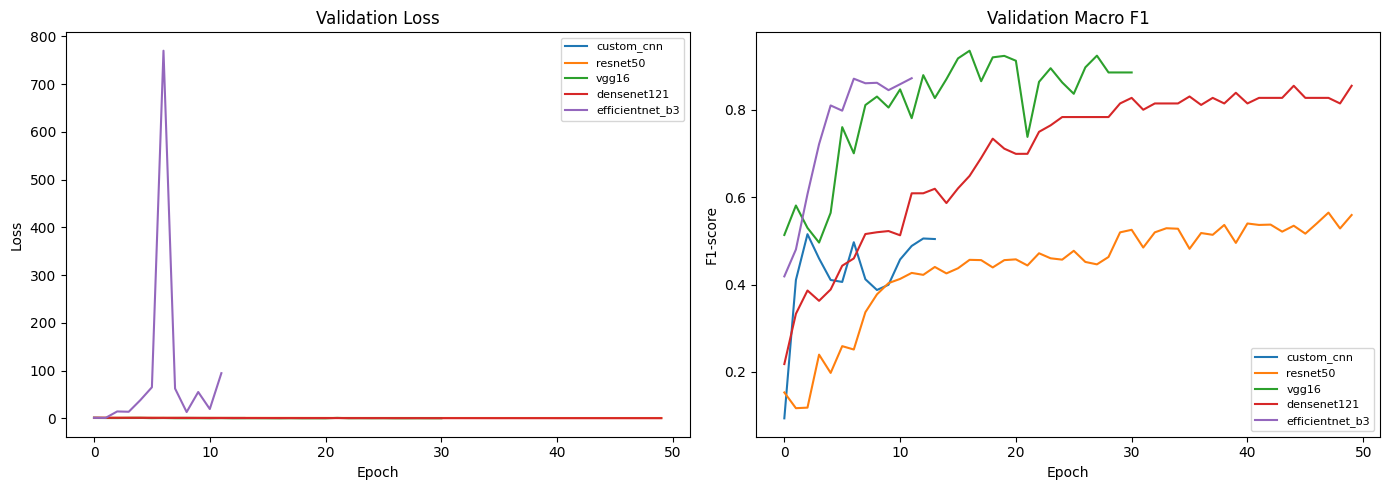

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, hist in training_histories.items():
    axes[0].plot(hist['val_loss'], label=model_name)
    axes[1].plot(hist['val_f1'], label=model_name)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150)
plt.show()

In [42]:
import json
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, roc_curve, confusion_matrix)
from sklearn.preprocessing import label_binarize

set_seed(SEED)

In [43]:
def load_trained_model(model_name, config, checkpoint_dir=CHECKPOINT_DIR):
    """Rebuilds the architecture and loads its best-checkpoint weights."""
    model = config['build_fn']().to(DEVICE)
    ckpt_path = Path(checkpoint_dir) / f"{model_name}_best.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"No checkpoint found at {ckpt_path}. Train the model in Part 2 first."
        )
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model


if 'trained_models' not in globals() or 'model_loaders' not in globals():
    print("Reloading models and dataloaders from checkpoints...")
    trained_models = {}
    model_loaders = {}
    for model_name, config in MODEL_REGISTRY.items():
        trained_models[model_name] = load_trained_model(model_name, config)
        model_loaders[model_name], _ = build_dataloaders(config['input_size'], config['batch_size'])
        print(f"  {model_name}: loaded.")
else:
    print("Reusing trained_models / model_loaders already in memory.")

MODEL_NAMES = list(MODEL_REGISTRY.keys())
print(f"\nModels ready for evaluation: {MODEL_NAMES}")

Reusing trained_models / model_loaders already in memory.

Models ready for evaluation: ['custom_cnn', 'resnet50', 'vgg16', 'densenet121', 'efficientnet_b3']


In [44]:
def get_predictions(model, loader, device=DEVICE):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    y_proba = np.vstack(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = y_proba.argmax(axis=1)
    return y_true, y_pred, y_proba

In [45]:
# Run inference for every model on its own test loader (input resolution
# differs for EfficientNet-B3, so each model uses the loader it was trained
# with). Results are cached in dicts keyed by model name.

test_predictions = {}   # model_name -> (y_true, y_pred, y_proba)
valid_predictions = {}  # needed later for ensemble weighting

for model_name in MODEL_NAMES:
    model = trained_models[model_name]
    loaders = model_loaders[model_name]
    test_predictions[model_name] = get_predictions(model, loaders['test'])
    valid_predictions[model_name] = get_predictions(model, loaders['valid'])
    print(f"{model_name}: test predictions collected "
          f"({len(test_predictions[model_name][0])} samples).")

# Sanity check: y_true should be identical across models (same underlying
# test set, just re-loaded at different resolutions/batch sizes).
reference_y_true = test_predictions[MODEL_NAMES[0]][0]
for name in MODEL_NAMES[1:]:
    if not np.array_equal(test_predictions[name][0], reference_y_true):
        print(f"WARNING: {name}'s test label order differs from {MODEL_NAMES[0]}'s. "
              "Ensemble averaging below assumes identical ordering — investigate "
              "before trusting ensemble results.")

custom_cnn: test predictions collected (315 samples).
resnet50: test predictions collected (315 samples).
vgg16: test predictions collected (315 samples).
densenet121: test predictions collected (315 samples).
efficientnet_b3: test predictions collected (315 samples).


### 6. Per-class metrics + confusion matrices (saved to disk)

In [46]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd

def log_per_class_metrics(name, y_true, y_pred, class_names):
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=range(len(class_names)))
    df = pd.DataFrame({
        'class': class_names, 'precision': p, 'recall': r, 'f1': f1, 'support': support
    })
    df.to_csv(RESULTS_DIR / "tables" / f"per_class_metrics_{name}.csv", index=False)
    manifest.setdefault("per_class_metrics", {})[name] = df.to_dict(orient="records")
    print(f"--- {name} per-class ---")
    print(df.round(4))

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(RESULTS_DIR / "tables" / f"confusion_matrix_{name}.csv")
    print(cm_df)
    return df, cm_df

# Per-model, using what this notebook already has in `test_predictions`:
for _name, (_y_true, _y_pred, _y_proba) in test_predictions.items():
    log_per_class_metrics(_name, _y_true, _y_pred, CLASS_NAMES)

# Ensemble:
import numpy as np

y_true_ens = next(iter(test_predictions.values()))[0]
avg_proba = np.mean([model_tuple[2] for model_tuple in test_predictions.values()], axis=0)
y_pred_ens = np.argmax(avg_proba, axis=1)
log_per_class_metrics('ensemble', y_true_ens, y_pred_ens, CLASS_NAMES)


--- custom_cnn per-class ---
                                              class  precision  recall  \
0        adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib     0.2308  0.0750   
1     large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa     0.4390  0.3529   
2                                            normal     1.0000  1.0000   
3  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa     0.3591  0.7222   

       f1  support  
0  0.1132      120  
1  0.3913       51  
2  1.0000       54  
3  0.4797       90  
                                                  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib  \
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib                                                 9   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa                                              5   
normal                                                                                     0   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa                                          25   

              

(                                              class  precision    recall  \
 0        adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib   0.962025  0.633333   
 1     large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa   0.923077  0.941176   
 2                                            normal   1.000000  1.000000   
 3  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa   0.684615  0.988889   
 
          f1  support  
 0  0.763819      120  
 1  0.932039       51  
 2  1.000000       54  
 3  0.809091       90  ,
                                                   adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib  \
 adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib                                                76   
 large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa                                              2   
 normal                                                                                     0   
 squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa                                           1   
 
     

In [47]:
def compute_metrics(y_true, y_pred, y_proba, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
    except ValueError:
        auc = float('nan')  # can happen if a class is absent from y_true
    return {'accuracy': acc, 'precision': precision, 'recall': recall,
            'f1': f1, 'auc_roc': auc}

In [48]:
rows = []
for model_name in MODEL_NAMES:
    y_true, y_pred, y_proba = test_predictions[model_name]
    m = compute_metrics(y_true, y_pred, y_proba)
    rows.append({'model': model_name, **m})

results_table = pd.DataFrame(rows).set_index('model')
results_table = results_table.round(4)
print(results_table)

results_table.to_csv(RESULTS_DIR / 'individual_model_metrics.csv')

                 accuracy  precision  recall      f1  auc_roc
model                                                        
custom_cnn         0.4635     0.5072  0.5375  0.4961   0.6794
resnet50           0.6286     0.7437  0.6041  0.6077   0.8570
vgg16              0.8095     0.8673  0.8630  0.8422   0.9860
densenet121        0.8476     0.8680  0.8550  0.8597   0.9619
efficientnet_b3    0.5365     0.6509  0.5761  0.5194   0.8104


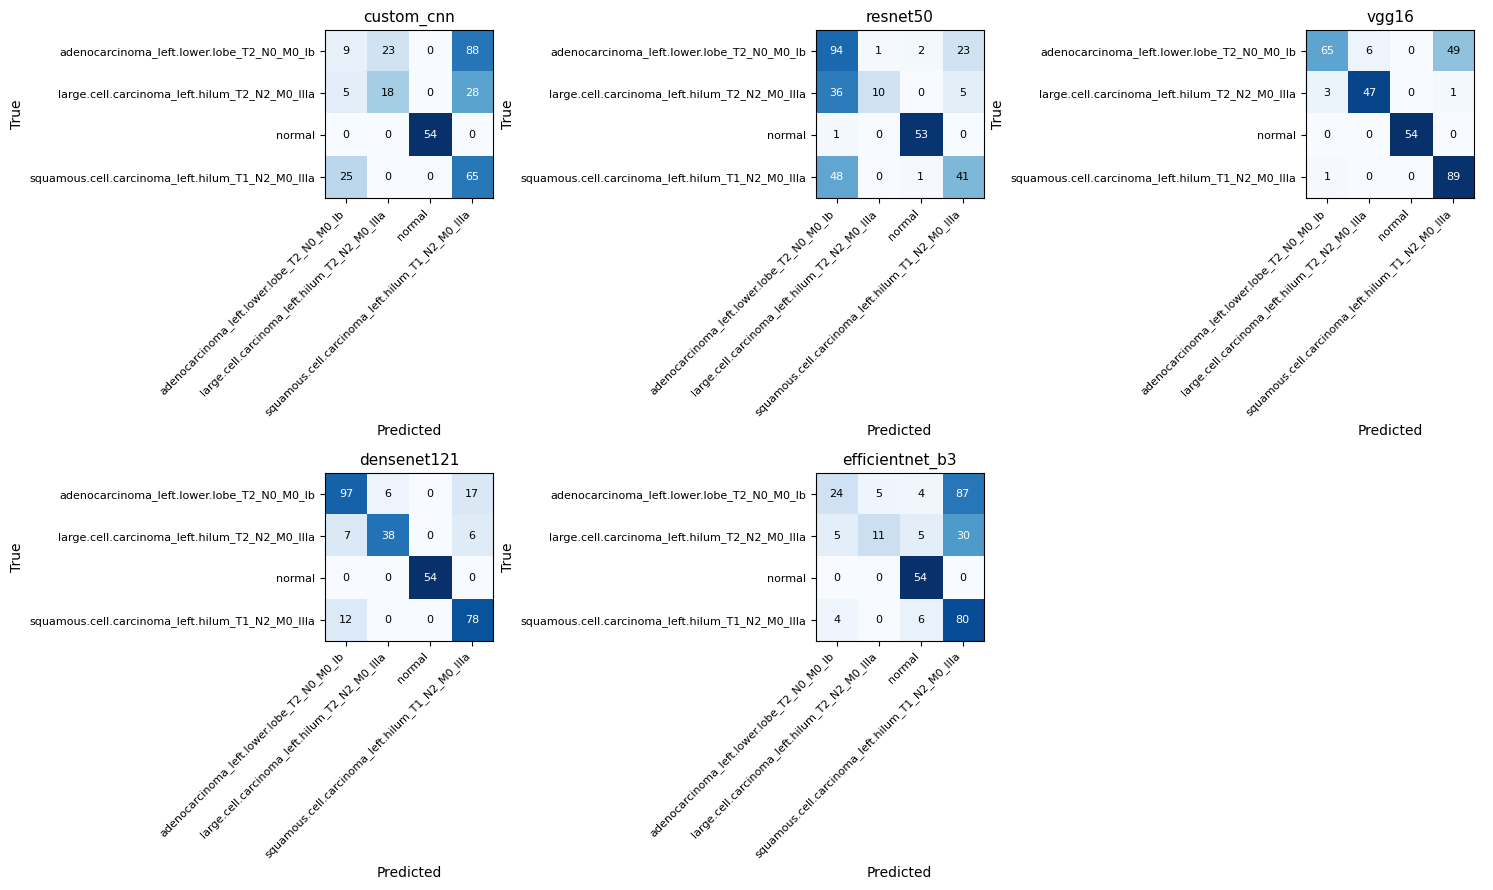

In [49]:
def plot_confusion_matrices(predictions_dict, class_names, ncols=3):
    n_models = len(predictions_dict)
    nrows = int(np.ceil(n_models / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (model_name, (y_true, y_pred, _)) in zip(axes, predictions_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(model_name, fontsize=11)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                         fontsize=8, color='white' if cm_norm[i, j] > 0.5 else 'black')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    for ax in axes[n_models:]:
        ax.axis('off')

    plt.tight_layout()
    return fig

fig = plot_confusion_matrices(test_predictions, CLASS_NAMES)
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

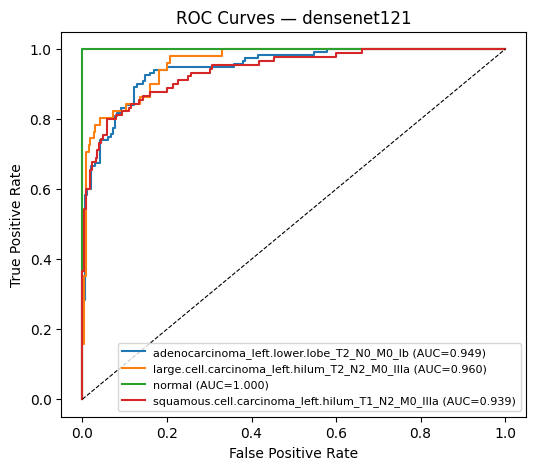

Best individual model by test accuracy: densenet121


In [50]:
def plot_roc_curves(model_name, y_true, y_proba, class_names):
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC={auc_i:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {model_name}')
    ax.legend(fontsize=8, loc='lower right')
    return fig

# Plot for the best individual model by test accuracy
best_model_name = results_table['accuracy'].idxmax()
y_true_b, _, y_proba_b = test_predictions[best_model_name]
fig = plot_roc_curves(best_model_name, y_true_b, y_proba_b, CLASS_NAMES)
plt.savefig(RESULTS_DIR / f'roc_curves_{best_model_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best individual model by test accuracy: {best_model_name}")

In [51]:
per_class_rows = []
for model_name in MODEL_NAMES:
    y_true, y_pred, _ = test_predictions[model_name]
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({'model': model_name, 'class': cls, 'precision': precision[i],
                                'recall': recall[i], 'f1': f1[i], 'support': support[i]})

per_class_df = pd.DataFrame(per_class_rows)
per_class_df = per_class_df[['model', 'class', 'precision', 'recall', 'f1', 'support']].round(4)
per_class_df.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)

# Pivot for a quick per-class F1 comparison across models
pivot_f1 = per_class_df.pivot(index='class', columns='model', values='f1')
print(pivot_f1.round(3))

model                                             custom_cnn  densenet121  \
class                                                                       
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib             0.113        0.822   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa          0.391        0.800   
normal                                                 1.000        1.000   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.480        0.817   

model                                             efficientnet_b3  resnet50  \
class                                                                         
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib                  0.314     0.629   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa               0.328     0.323   
normal                                                      0.878     0.964   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa            0.558     0.516   

model                                             vgg16  
clas

In [52]:
# Which class is hardest overall, and what does it get confused with most?
for model_name in [best_model_name]:
    y_true, y_pred, _ = test_predictions[model_name]
    cm = confusion_matrix(y_true, y_pred)
    cm_off_diag = cm.copy()
    np.fill_diagonal(cm_off_diag, 0)
    print(f"\n[{model_name}] Most common confusions:")
    idxs = np.dstack(np.unravel_index(np.argsort(-cm_off_diag.ravel()), cm_off_diag.shape))[0]
    for i, j in idxs[:5]:
        if cm_off_diag[i, j] > 0:
            print(f"  True={CLASS_NAMES[i]:<25} Predicted={CLASS_NAMES[j]:<25} count={cm[i,j]}")


[densenet121] Most common confusions:
  True=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib Predicted=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa count=17
  True=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa Predicted=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib count=12
  True=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa Predicted=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib count=7
  True=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa Predicted=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa count=6
  True=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib Predicted=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa count=6


In [53]:
def validation_f1(model_name):
    y_true, y_pred, _ = valid_predictions[model_name]
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return f1

val_f1_scores = {name: validation_f1(name) for name in MODEL_NAMES}
print("Validation macro F1 per model:")
for name, score in sorted(val_f1_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:<18} {score:.4f}")

Validation macro F1 per model:
  vgg16              0.9128
  densenet121        0.8555
  resnet50           0.5595
  efficientnet_b3    0.4805
  custom_cnn         0.4599


In [54]:
def pairwise_agreement(predictions_dict):
    """Fraction of test samples where each pair of models agrees on the
    predicted class (diversity check)."""
    names = list(predictions_dict.keys())
    agreement = pd.DataFrame(index=names, columns=names, dtype=float)
    for a, b in itertools.product(names, names):
        pred_a = predictions_dict[a][1]
        pred_b = predictions_dict[b][1]
        agreement.loc[a, b] = (pred_a == pred_b).mean()
    return agreement

agreement_matrix = pairwise_agreement(test_predictions)
print("Pairwise prediction agreement (test set):")
print(agreement_matrix.round(3))

Pairwise prediction agreement (test set):
                 custom_cnn  resnet50  vgg16  densenet121  efficientnet_b3
custom_cnn            1.000     0.381  0.578        0.508            0.629
resnet50              0.381     1.000  0.530        0.673            0.460
vgg16                 0.578     0.530  1.000        0.759            0.648
densenet121           0.508     0.673  0.759        1.000            0.562
efficientnet_b3       0.629     0.460  0.648        0.562            1.000


In [55]:
# Constituent selection: top-3 by validation F1, by default. Override
# ENSEMBLE_MODELS manually below if the agreement matrix above shows one of
# the top-3 is too redundant with another (e.g. >0.95 agreement) — swap it
# for the next-best, less-correlated model instead.

top3_by_f1 = sorted(val_f1_scores, key=val_f1_scores.get, reverse=True)[:3]
print(f"Top-3 by validation F1: {top3_by_f1}")

ENSEMBLE_MODELS = top3_by_f1  # <-- override manually here if needed, e.g.:
# ENSEMBLE_MODELS = ['efficientnet_b3', 'densenet121', 'resnet50']

print(f"Ensemble constituents in use: {ENSEMBLE_MODELS}")
print("\nPairwise agreement among selected constituents:")
print(agreement_matrix.loc[ENSEMBLE_MODELS, ENSEMBLE_MODELS].round(3))

Top-3 by validation F1: ['vgg16', 'densenet121', 'resnet50']
Ensemble constituents in use: ['vgg16', 'densenet121', 'resnet50']

Pairwise agreement among selected constituents:
             vgg16  densenet121  resnet50
vgg16        1.000        0.759     0.530
densenet121  0.759        1.000     0.673
resnet50     0.530        0.673     1.000


In [56]:
def build_ensemble_predictions(model_names, predictions_dict, weight_scores):
    """Weighted soft voting: each model's probability vector is scaled by
    its (normalised) weight, then summed. Weights are proportional to each
    model's validation F1-score."""
    weights = np.array([weight_scores[name] for name in model_names])
    weights = weights / weights.sum()

    y_true_ref = predictions_dict[model_names[0]][0]
    combined_proba = np.zeros_like(predictions_dict[model_names[0]][2])
    for name, w in zip(model_names, weights):
        combined_proba += w * predictions_dict[name][2]

    y_pred_ensemble = combined_proba.argmax(axis=1)
    return y_true_ref, y_pred_ensemble, combined_proba, dict(zip(model_names, weights))


y_true_ens, y_pred_ens, proba_ens, ensemble_weights = build_ensemble_predictions(
    ENSEMBLE_MODELS, test_predictions, val_f1_scores)

print("Ensemble weights (normalised, proportional to validation F1):")
for name, w in ensemble_weights.items():
    print(f"  {name:<18} {w:.4f}")

ensemble_metrics = compute_metrics(y_true_ens, y_pred_ens, proba_ens)
print("\nEnsemble test-set metrics:")
for k, v in ensemble_metrics.items():
    print(f"  {k:<10} {v:.4f}")

Ensemble weights (normalised, proportional to validation F1):
  vgg16              0.3921
  densenet121        0.3675
  resnet50           0.2404

Ensemble test-set metrics:
  accuracy   0.8667
  precision  0.8985
  recall     0.9033
  f1         0.8897
  auc_roc    0.9859


In [57]:
# Add the ensemble row to the results table alongside the individual models
ensemble_row = pd.DataFrame([{'model': 'ensemble', **ensemble_metrics}]).set_index('model')
results_table_full = pd.concat([results_table, ensemble_row.round(4)])
print(results_table_full)

results_table_full.to_csv(RESULTS_DIR / 'all_model_metrics_incl_ensemble.csv')

                 accuracy  precision  recall      f1  auc_roc
model                                                        
custom_cnn         0.4635     0.5072  0.5375  0.4961   0.6794
resnet50           0.6286     0.7437  0.6041  0.6077   0.8570
vgg16              0.8095     0.8673  0.8630  0.8422   0.9860
densenet121        0.8476     0.8680  0.8550  0.8597   0.9619
efficientnet_b3    0.5365     0.6509  0.5761  0.5194   0.8104
ensemble           0.8667     0.8985  0.9033  0.8897   0.9859


In [58]:
!pip install -q statsmodels

In [59]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemars_comparison(y_true, y_pred_a, y_pred_b, name_a='A', name_b='B'):
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)

    only_a_correct = int(np.sum(correct_a & ~correct_b))
    only_b_correct = int(np.sum(~correct_a & correct_b))

    table = [[0, only_a_correct], [only_b_correct, 0]]
    exact = (only_a_correct + only_b_correct) < 25
    result = mcnemar(table, exact=exact, correction=not exact)

    print(f"{name_a} correct / {name_b} wrong: {only_a_correct}")
    print(f"{name_b} correct / {name_a} wrong: {only_b_correct}")
    print(f"McNemar's test statistic={result.statistic:.4f}, p-value={result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print("=> Statistically significant difference (p < 0.05).")
    else:
        print("=> No statistically significant difference at p < 0.05.")
    return result


best_individual = results_table['accuracy'].idxmax()
y_true_best, y_pred_best, _ = test_predictions[best_individual]

print(f"Comparing ensemble vs. best individual model ({best_individual}):\n")
mcnemars_comparison(y_true_ens, y_pred_ens, y_pred_best,
                     name_a='ensemble', name_b=best_individual)

Comparing ensemble vs. best individual model (densenet121):

ensemble correct / densenet121 wrong: 29
densenet121 correct / ensemble wrong: 23
McNemar's test statistic=0.4808, p-value=0.4881
=> No statistically significant difference at p < 0.05.


<bunch containing results, print to see contents>

In [60]:
# Which specific cases does the ensemble rescue that the best individual
# model got wrong?
rescued_mask = (y_pred_ens == y_true_ens) & (y_pred_best != y_true_ens)
n_rescued = int(rescued_mask.sum())
print(f"Test cases the ensemble got right but {best_individual} got wrong: {n_rescued}")

if n_rescued > 0:
    rescued_idx = np.where(rescued_mask)[0][:10]
    print("\nSample rescued cases (true class / best-model prediction / ensemble prediction):")
    for idx in rescued_idx:
        print(f"  true={CLASS_NAMES[y_true_ens[idx]]:<25} "
              f"{best_individual}={CLASS_NAMES[y_pred_best[idx]]:<25} "
              f"ensemble={CLASS_NAMES[y_pred_ens[idx]]}")

Test cases the ensemble got right but densenet121 got wrong: 29

Sample rescued cases (true class / best-model prediction / ensemble prediction):
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib densenet121=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib densenet121=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib densenet121=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib densenet121=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib densenet121=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N

### 7. All-pairs McNemar's test

In [61]:
from itertools import combinations

def all_pairs_mcnemar(test_predictions, ensemble_true=None, ensemble_pred=None,
                       ensemble_name='ensemble'):
    preds = {name: (t[0], t[1]) for name, t in test_predictions.items()}
    if ensemble_pred is not None:
        preds[ensemble_name] = (ensemble_true, ensemble_pred)

    rows = []
    for a, b in combinations(preds.keys(), 2):
        y_true_a, y_pred_a = preds[a]
        _, y_pred_b = preds[b]
        result = mcnemars_comparison(y_true_a, y_pred_a, y_pred_b, name_a=a, name_b=b)
        rows.append({'model_a': a, 'model_b': b,
                      'statistic': result.statistic, 'p_value': result.pvalue})
    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_DIR / "tables" / "mcnemar_all_pairs.csv", index=False)
    manifest["mcnemar_all_pairs"] = df.to_dict(orient="records")
    return df

mcnemar_df = all_pairs_mcnemar(test_predictions, ensemble_true=y_true_ens, ensemble_pred=y_pred_ens)
print(mcnemar_df.round(4))


custom_cnn correct / resnet50 wrong: 61
resnet50 correct / custom_cnn wrong: 113
McNemar's test statistic=14.9483, p-value=0.0001
=> Statistically significant difference (p < 0.05).
custom_cnn correct / vgg16 wrong: 5
vgg16 correct / custom_cnn wrong: 114
McNemar's test statistic=98.0168, p-value=0.0000
=> Statistically significant difference (p < 0.05).
custom_cnn correct / densenet121 wrong: 12
densenet121 correct / custom_cnn wrong: 133
McNemar's test statistic=99.3103, p-value=0.0000
=> Statistically significant difference (p < 0.05).
custom_cnn correct / efficientnet_b3 wrong: 31
efficientnet_b3 correct / custom_cnn wrong: 54
McNemar's test statistic=5.6941, p-value=0.0170
=> Statistically significant difference (p < 0.05).
custom_cnn correct / ensemble wrong: 4
ensemble correct / custom_cnn wrong: 131
McNemar's test statistic=117.6000, p-value=0.0000
=> Statistically significant difference (p < 0.05).
resnet50 correct / vgg16 wrong: 43
vgg16 correct / resnet50 wrong: 100
McNemar'

In [62]:
import pickle

predictions_to_save = {name: {'y_true': yt.tolist(), 'y_pred': yp.tolist(),
                               'y_proba': ypr.tolist()}
                        for name, (yt, yp, ypr) in test_predictions.items()}
predictions_to_save['ensemble'] = {'y_true': y_true_ens.tolist(),
                                    'y_pred': y_pred_ens.tolist(),
                                    'y_proba': proba_ens.tolist()}

with open(RESULTS_DIR / 'test_predictions.pkl', 'wb') as f:
    pickle.dump(predictions_to_save, f)

ensemble_config = {'constituent_models': ENSEMBLE_MODELS, 'weights': ensemble_weights}
with open(RESULTS_DIR / 'ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)

print("Saved:")
print(f"  {RESULTS_DIR / 'test_predictions.pkl'}")
print(f"  {RESULTS_DIR / 'ensemble_config.json'}")
print(f"  {RESULTS_DIR / 'individual_model_metrics.csv'}")
print(f"  {RESULTS_DIR / 'all_model_metrics_incl_ensemble.csv'}")
print(f"  {RESULTS_DIR / 'per_class_metrics.csv'}")

Saved:
  /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/test_predictions.pkl
  /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/ensemble_config.json
  /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/individual_model_metrics.csv
  /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/all_model_metrics_incl_ensemble.csv
  /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/per_class_metrics.csv


In [63]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.cm as cm

set_seed(SEED)

GRADCAM_DIR = RESULTS_DIR / 'gradcam'
GRADCAM_DIR.mkdir(exist_ok=True)

In [64]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self._bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        """input_tensor: [1, C, H, W]. Returns a [H, W] numpy heatmap in [0, 1],
        and the (possibly auto-selected) target class index used."""
        self.model.zero_grad()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[0, target_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))  # [1, 1, h, w]
        cam = cam.squeeze().cpu().numpy()

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, target_class

    def remove_hooks(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()

In [65]:
def get_target_layer(model, model_name):
    if model_name == 'custom_cnn':
        return model.features[-1][0]  # last block's Conv2d
    elif model_name == 'resnet50':
        return model.layer4[-1]  # last residual block, stage 4
    elif model_name == 'vgg16':
        for layer in reversed(model.features):
            if isinstance(layer, nn.Conv2d):
                return layer
        raise ValueError("No Conv2d found in VGG-16 features.")
    elif model_name == 'densenet121':
        return model.features  # dense block output, pre-classifier
    elif model_name == 'efficientnet_b3':
        return model.features[-1]  # final conv block before pooling
    else:
        raise ValueError(f"No target layer defined for {model_name}")

# Sanity check: confirm each model resolves to a real module
for name, model in trained_models.items():
    layer = get_target_layer(model, name)
    print(f"{name}: target layer = {layer.__class__.__name__}")

custom_cnn: target layer = Conv2d
resnet50: target layer = Bottleneck
vgg16: target layer = Conv2d
densenet121: target layer = Sequential
efficientnet_b3: target layer = Conv2dNormActivation


In [66]:
def denormalise(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (img_tensor.cpu() * std_t + mean_t).clamp(0, 1)


def overlay_heatmap(image_rgb, cam, alpha=0.45):
    """image_rgb: HxWx3 in [0,1]. cam: hxw in [0,1] (conv feature map size).
    Returns an HxWx3 blended image."""
    h, w = image_rgb.shape[:2]
    cam_resized = torch.nn.functional.interpolate(
        torch.tensor(cam)[None, None, :, :], size=(h, w), mode='bilinear', align_corners=False
    ).squeeze().numpy()
    heatmap = cm.jet(cam_resized)[:, :, :3]  # drop alpha channel
    blended = (1 - alpha) * image_rgb + alpha * heatmap
    return np.clip(blended, 0, 1)

In [67]:
def collect_sample_indices(y_true, y_pred, class_names, n_correct=20, n_wrong=5, seed=SEED):
    """For each class, returns up to n_correct correctly-classified and
    n_wrong misclassified test-set sample indices."""
    rng = np.random.default_rng(seed)
    samples = {}
    for cls_idx, cls_name in enumerate(class_names):
        class_mask = (y_true == cls_idx)
        correct_idx = np.where(class_mask & (y_pred == y_true))[0]
        wrong_idx = np.where(class_mask & (y_pred != y_true))[0]

        chosen_correct = rng.choice(correct_idx, size=min(n_correct, len(correct_idx)), replace=False)
        chosen_wrong = rng.choice(wrong_idx, size=min(n_wrong, len(wrong_idx)), replace=False)
        samples[cls_name] = {'correct': chosen_correct.tolist(), 'wrong': chosen_wrong.tolist()}
    return samples


GRADCAM_MODEL_NAME = results_table['accuracy'].idxmax()
print(f"Generating Grad-CAM for: {GRADCAM_MODEL_NAME}")

y_true_gc, y_pred_gc, _ = test_predictions[GRADCAM_MODEL_NAME]
sample_indices = collect_sample_indices(y_true_gc, y_pred_gc, CLASS_NAMES)
for cls, d in sample_indices.items():
    print(f"  {cls}: {len(d['correct'])} correct, {len(d['wrong'])} misclassified samples selected")

Generating Grad-CAM for: densenet121
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 20 correct, 5 misclassified samples selected
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 20 correct, 5 misclassified samples selected
  normal: 20 correct, 0 misclassified samples selected
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 20 correct, 5 misclassified samples selected


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


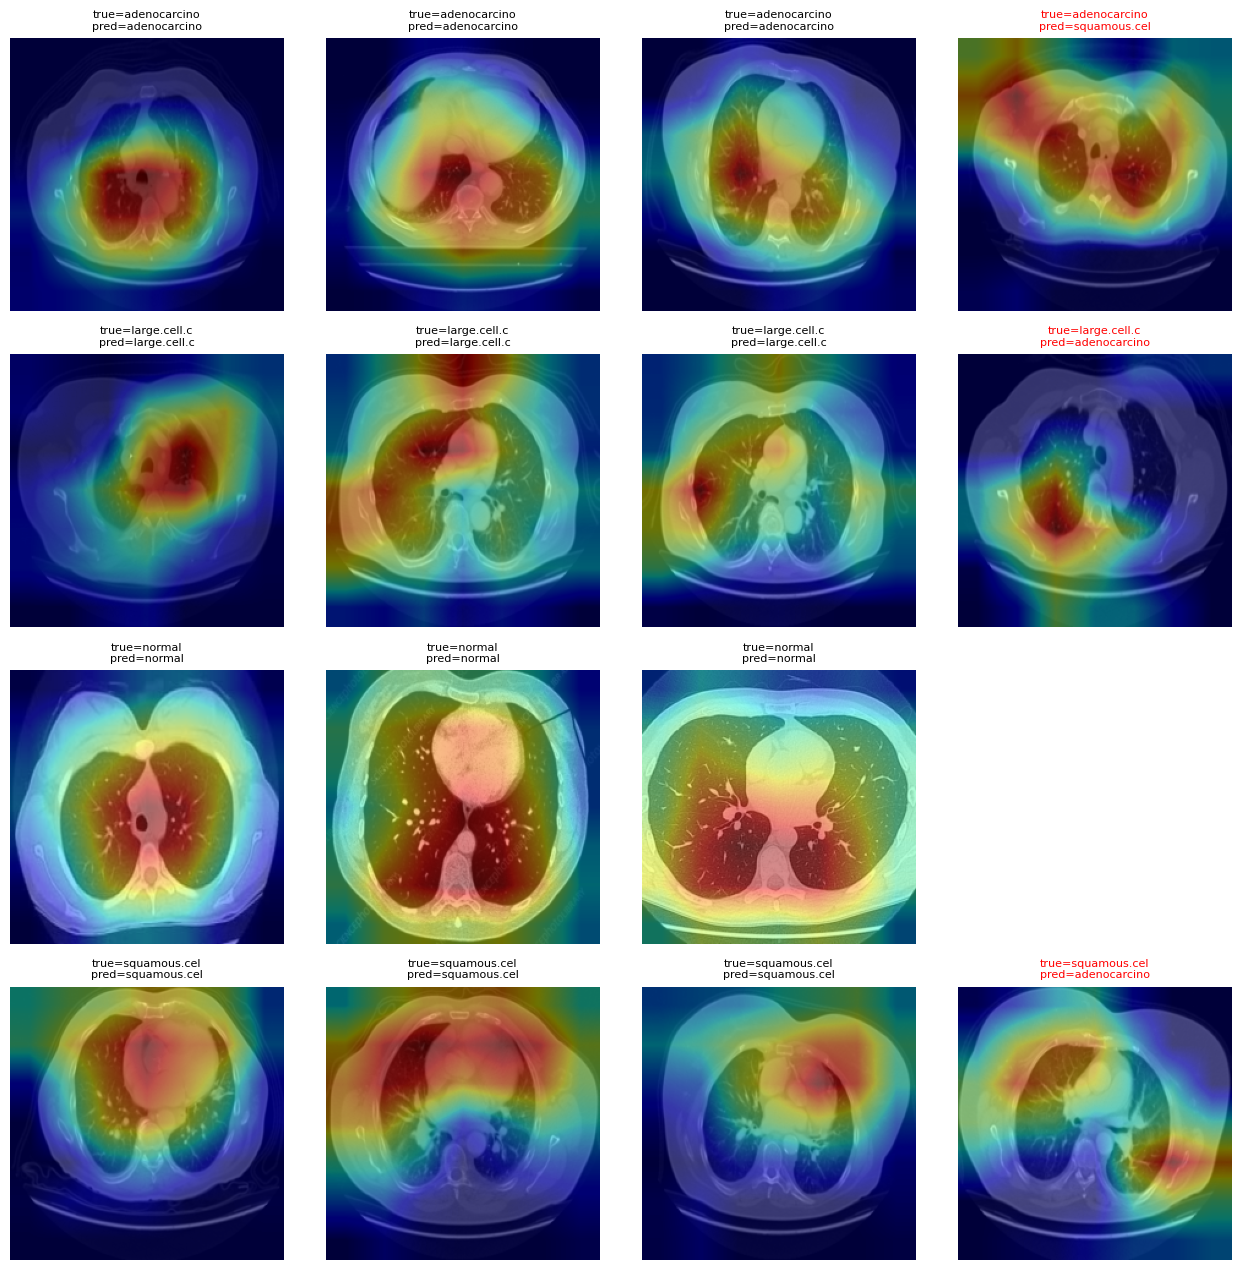


Red titles = misclassified example included for that class.


In [68]:
def get_test_image_tensor(model_name, flat_index):
    """Retrieves the tensor and label for a given flat index into that model's test dataset."""
    dataset = model_loaders[model_name]['test'].dataset
    img_tensor, label = dataset[flat_index]
    return img_tensor.unsqueeze(0), label


def visualise_gradcam_grid(model_name, sample_indices, class_names, n_show_per_class=4,
                            save_path=None):
    model = trained_models[model_name]

    # Disable inplace on all ReLU modules recursively — required for Grad-CAM's
    # backward hooks to work correctly (inplace ReLU corrupts saved activations)
    for m in model.modules():
        if hasattr(m, 'inplace'):
            m.inplace = False

    target_layer = get_target_layer(model, model_name)
    gradcam = GradCAM(model, target_layer)

    fig, axes = plt.subplots(len(class_names), n_show_per_class,
                             figsize=(3.2 * n_show_per_class, 3.2 * len(class_names)))

    # Monkey-patch functional ReLU calls during Grad-CAM generation, in case
    # any inplace ReLU calls happen via F.relu rather than the nn.ReLU module
    orig_f_relu = F.relu
    orig_torch_relu_ = torch.relu_

    def safe_f_relu(input, inplace=False):
        return orig_f_relu(input, inplace=False)

    def safe_torch_relu_(input):
        return torch.relu(input)

    F.relu = safe_f_relu
    torch.relu_ = safe_torch_relu_

    try:
        for row, cls_name in enumerate(class_names):
            idxs = sample_indices[cls_name]['correct'][:n_show_per_class - 1]
            if sample_indices[cls_name]['wrong']:
                idxs = idxs[:n_show_per_class - 1] + [sample_indices[cls_name]['wrong'][0]]
            idxs = idxs[:n_show_per_class]

            for col in range(n_show_per_class):
                ax = axes[row, col] if len(class_names) > 1 else axes[col]
                if col >= len(idxs):
                    ax.axis('off')
                    continue

                flat_idx = idxs[col]
                img_tensor, true_label = get_test_image_tensor(model_name, flat_idx)
                img_tensor = img_tensor.to(DEVICE)
                img_tensor.requires_grad_(False)

                cam, pred_class = gradcam.generate_cam(img_tensor.clone())

                img_rgb = denormalise(img_tensor[0]).permute(1, 2, 0).detach().cpu().numpy()
                blended = overlay_heatmap(img_rgb, cam)

                ax.imshow(blended)
                is_wrong = idxs[col] in sample_indices[cls_name]['wrong']
                title_color = 'red' if is_wrong else 'black'
                ax.set_title(f"true={class_names[true_label][:12]}\npred={class_names[pred_class][:12]}",
                             fontsize=8, color=title_color)
                ax.axis('off')
    finally:
        F.relu = orig_f_relu
        torch.relu_ = orig_torch_relu_
        gradcam.remove_hooks()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig


fig = visualise_gradcam_grid(GRADCAM_MODEL_NAME, sample_indices, CLASS_NAMES,
                             save_path=GRADCAM_DIR / f'gradcam_grid_{GRADCAM_MODEL_NAME}.png')
plt.show()
print("\nRed titles = misclassified example included for that class.")

In [69]:
def heatmap_spread_metrics(cam):
    """cam: 2D array in [0,1]. Returns (entropy, centroid_y, centroid_x)
    with centroid in normalised [0,1] coordinates."""
    flat = cam.flatten()
    prob = flat / (flat.sum() + 1e-12)
    prob_nonzero = prob[prob > 0]
    entropy = float(-(prob_nonzero * np.log2(prob_nonzero)).sum())

    h, w = cam.shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy = float((prob.reshape(h, w) * yy).sum() / h)
    cx = float((prob.reshape(h, w) * xx).sum() / w)
    return entropy, cy, cx


def compute_gradcam_spread_stats(model_name, y_true, y_pred, n_per_group=60, seed=SEED):
    """Samples up to n_per_group correct and misclassified test cases and
    computes heatmap-spread metrics for each, to compare distributions."""
    rng = np.random.default_rng(seed)
    model = trained_models[model_name]

    for m in model.modules():
        if hasattr(m, 'inplace'):
            m.inplace = False

    target_layer = get_target_layer(model, model_name)
    gradcam = GradCAM(model, target_layer)

    correct_idx = np.where(y_pred == y_true)[0]
    wrong_idx = np.where(y_pred != y_true)[0]
    correct_sample = rng.choice(correct_idx, size=min(n_per_group, len(correct_idx)), replace=False)
    wrong_sample = rng.choice(wrong_idx, size=min(n_per_group, len(wrong_idx)), replace=False)

    rows = []

    orig_f_relu = F.relu
    orig_torch_relu_ = torch.relu_

    def safe_f_relu(input, inplace=False):
        return orig_f_relu(input, inplace=False)

    def safe_torch_relu_(input):
        return torch.relu(input)

    F.relu = safe_f_relu
    torch.relu_ = safe_torch_relu_

    try:
        for group_name, idx_list in [('correct', correct_sample), ('misclassified', wrong_sample)]:
            for idx in idx_list:
                img_tensor, _ = get_test_image_tensor(model_name, int(idx))
                img_tensor = img_tensor.to(DEVICE)
                img_tensor.requires_grad_(False)

                cam, _ = gradcam.generate_cam(img_tensor.clone())
                entropy, cy, cx = heatmap_spread_metrics(cam)
                rows.append({'group': group_name, 'entropy': entropy, 'centroid_y': cy, 'centroid_x': cx})
    finally:
        F.relu = orig_f_relu
        torch.relu_ = orig_torch_relu_
        gradcam.remove_hooks()

    return pd.DataFrame(rows)


spread_df = compute_gradcam_spread_stats(GRADCAM_MODEL_NAME, y_true_gc, y_pred_gc)
print(spread_df.groupby('group')['entropy'].agg(['mean', 'std', 'count']))

spread_df.to_csv(GRADCAM_DIR / f'heatmap_spread_{GRADCAM_MODEL_NAME}.csv', index=False)

                   mean       std  count
group                                   
correct        5.010502  0.348669     60
misclassified  4.736071  0.294266     48


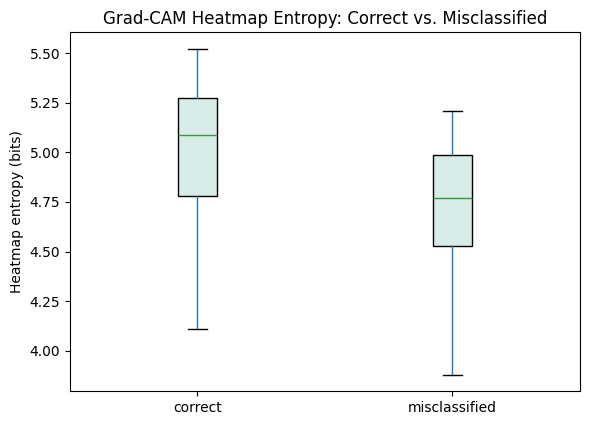

Higher entropy on misclassified cases would be *consistent* with errors
clustering on ambiguous, diffusely-activated regions — but treat this as
a hint to investigate, not confirmation. Always eyeball the heatmap grid too.


In [70]:
fig, ax = plt.subplots(figsize=(6, 4.5))
spread_df.boxplot(column='entropy', by='group', ax=ax, grid=False,
                   patch_artist=True, boxprops=dict(facecolor='#D7ECE8'))
ax.set_title('Grad-CAM Heatmap Entropy: Correct vs. Misclassified')
ax.set_xlabel('')
ax.set_ylabel('Heatmap entropy (bits)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'heatmap_entropy_comparison.png', dpi=150)
plt.show()

print("Higher entropy on misclassified cases would be *consistent* with errors")
print("clustering on ambiguous, diffusely-activated regions — but treat this as")
print("a hint to investigate, not confirmation. Always eyeball the heatmap grid too.")

In [71]:
def enable_mc_dropout(model):
    """Puts the whole model in eval() mode (correct BatchNorm behaviour),
    then switches only Dropout submodules back to train() mode so they
    remain stochastic across the T forward passes."""
    model.eval()
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d)):
            module.train()


def model_has_dropout(model):
    return any(isinstance(m, (nn.Dropout, nn.Dropout2d)) for m in model.modules())


@torch.no_grad()
def mc_dropout_predict(model, images, T=50):
    """images: [B, C, H, W] tensor, already on DEVICE.
    Returns mean_proba [B, C], entropy [B], std_proba [B, C]."""
    enable_mc_dropout(model)
    all_probs = []
    for _ in range(T):
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.unsqueeze(0))
    all_probs = torch.cat(all_probs, dim=0)  # [T, B, num_classes]

    mean_proba = all_probs.mean(dim=0)
    std_proba = all_probs.std(dim=0)
    entropy = -(mean_proba * torch.log(mean_proba.clamp_min(1e-12))).sum(dim=1)

    model.eval()  # restore full eval mode when done
    return mean_proba.cpu().numpy(), entropy.cpu().numpy(), std_proba.cpu().numpy()

In [72]:
def run_mc_dropout_over_loader(model, loader, T=50):
    """Runs MC Dropout batch-by-batch over a full DataLoader."""
    all_mean_proba, all_entropy, all_labels = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        mean_proba, entropy, _ = mc_dropout_predict(model, images, T=T)
        all_mean_proba.append(mean_proba)
        all_entropy.append(entropy)
        all_labels.append(labels.numpy())
    return (np.concatenate(all_labels),
            np.vstack(all_mean_proba),
            np.concatenate(all_entropy))


# Fixed: previously defaulted straight to GRADCAM_MODEL_NAME (best-accuracy
# model), which silently produces zero variance if that model is ResNet-50 or
# DenseNet-121 — neither has a Dropout layer, so all T passes are identical
# and "entropy" becomes a meaningless deterministic function of the softmax.
MC_DROPOUT_MODEL_NAME = GRADCAM_MODEL_NAME
if not model_has_dropout(trained_models[MC_DROPOUT_MODEL_NAME]):
    dropout_models = [n for n in MODEL_NAMES if model_has_dropout(trained_models[n])]
    if not dropout_models:
        raise RuntimeError("No trained model has a Dropout layer — MC Dropout is not applicable.")
    MC_DROPOUT_MODEL_NAME = max(dropout_models, key=lambda n: val_f1_scores[n])
    print(f"{GRADCAM_MODEL_NAME} has no Dropout layers — MC Dropout would be "
          f"meaningless (zero variance across passes). Using {MC_DROPOUT_MODEL_NAME} "
          f"instead (best dropout-having model by validation F1).")

mc_model = trained_models[MC_DROPOUT_MODEL_NAME]
mc_loaders = model_loaders[MC_DROPOUT_MODEL_NAME]

print(f"Running MC Dropout (T=50) on {MC_DROPOUT_MODEL_NAME}'s test set — this takes a while "
      "(50x the normal inference cost)...")

y_true_mc, mean_proba_mc, entropy_mc = run_mc_dropout_over_loader(mc_model, mc_loaders['test'], T=50)
y_pred_mc = mean_proba_mc.argmax(axis=1)

print(f"Done. {len(y_true_mc)} test samples processed.")
print(f"Entropy range: [{entropy_mc.min():.4f}, {entropy_mc.max():.4f}], "
      f"mean={entropy_mc.mean():.4f}")

densenet121 has no Dropout layers — MC Dropout would be meaningless (zero variance across passes). Using vgg16 instead (best dropout-having model by validation F1).
Running MC Dropout (T=50) on vgg16's test set — this takes a while (50x the normal inference cost)...
Done. 315 test samples processed.
Entropy range: [0.0000, 1.3453], mean=0.3727


In [73]:
def quartile_accuracy_table(y_true, y_pred, entropy):
    quartile_edges = np.percentile(entropy, [0, 25, 50, 75, 100])
    labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
    rows = []
    for i, label in enumerate(labels):
        lo, hi = quartile_edges[i], quartile_edges[i + 1]
        if i < 3:
            mask = (entropy >= lo) & (entropy < hi)
        else:
            mask = (entropy >= lo) & (entropy <= hi)
        acc = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else float('nan')
        rows.append({
            'quartile': label,
            'entropy_range': f"[{lo:.3f}, {hi:.3f})" if i < 3 else f"[{lo:.3f}, {hi:.3f}]",
            'pct_of_test_set': 100 * mask.sum() / len(entropy),
            'accuracy': acc,
            'n_samples': int(mask.sum()),
        })
    return pd.DataFrame(rows)

quartile_table = quartile_accuracy_table(y_true_mc, y_pred_mc, entropy_mc)
print(quartile_table.round(4))
quartile_table.to_csv(RESULTS_DIR / 'uncertainty_quartile_table.csv', index=False)

    quartile   entropy_range  pct_of_test_set  accuracy  n_samples
0   Q1 (Low)  [0.000, 0.010)          25.0794    1.0000         79
1         Q2  [0.010, 0.276)          24.7619    0.9615         78
2         Q3  [0.276, 0.688)          25.0794    0.7468         79
3  Q4 (High)  [0.688, 1.345]          25.0794    0.4937         79


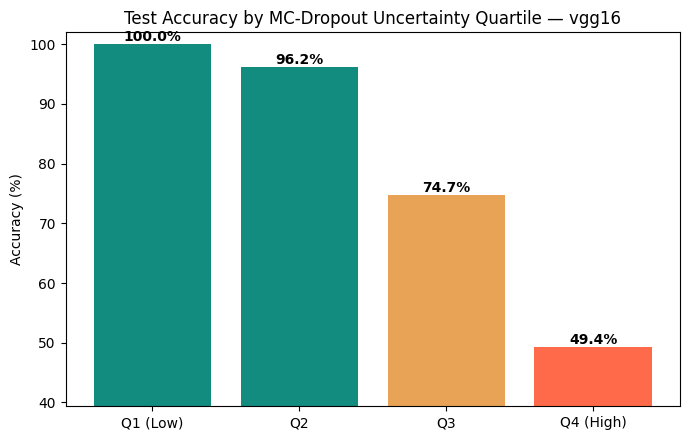

In [74]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#128C7E', '#128C7E', '#E8A356', '#FF6B4A']
bars = ax.bar(quartile_table['quartile'], quartile_table['accuracy'] * 100, color=colors)
for bar, acc in zip(bars, quartile_table['accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc*100:.1f}%", ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Test Accuracy by MC-Dropout Uncertainty Quartile — {MC_DROPOUT_MODEL_NAME}')
ax.set_ylim(min(quartile_table['accuracy'] * 100) - 10, 102)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'accuracy_by_uncertainty_quartile.png', dpi=150)
plt.show()

In [75]:
print("Running MC Dropout (T=50) on the training set to calibrate the threshold "
      "— this is the slowest step in this notebook.")

y_true_train_mc, mean_proba_train_mc, entropy_train_mc = run_mc_dropout_over_loader(
    mc_model, mc_loaders['train'], T=50)

REVIEW_THRESHOLD = float(np.percentile(entropy_train_mc, 90))
print(f"\nReview threshold (90th percentile of training entropy): {REVIEW_THRESHOLD:.4f}")

Running MC Dropout (T=50) on the training set to calibrate the threshold — this is the slowest step in this notebook.

Review threshold (90th percentile of training entropy): 0.2222


In [76]:
flagged_mask = entropy_mc > REVIEW_THRESHOLD
n_flagged = int(flagged_mask.sum())
pct_flagged = 100 * n_flagged / len(entropy_mc)

flagged_correct = (y_pred_mc[flagged_mask] == y_true_mc[flagged_mask]).sum()
flagged_error_rate = 100 * (1 - flagged_correct / n_flagged) if n_flagged > 0 else float('nan')

total_errors = int((y_pred_mc != y_true_mc).sum())
errors_in_flagged = int((y_pred_mc[flagged_mask] != y_true_mc[flagged_mask]).sum())
pct_errors_caught = 100 * errors_in_flagged / total_errors if total_errors > 0 else float('nan')

print(f"Flagged for review: {n_flagged}/{len(entropy_mc)} test cases ({pct_flagged:.1f}%)")
print(f"Error rate within flagged subset: {flagged_error_rate:.1f}%")
print(f"Total model errors on test set: {total_errors}")
print(f"Of those, caught by flagging: {errors_in_flagged} ({pct_errors_caught:.1f}%)")

Flagged for review: 165/315 test cases (52.4%)
Error rate within flagged subset: 36.4%
Total model errors on test set: 63
Of those, caught by flagging: 60 (95.2%)


In [77]:
def operational_summary(pct_flagged, flagged_error_rate, n_scans=1000):
    n_flagged = round(n_scans * pct_flagged / 100)
    n_auto = n_scans - n_flagged
    n_genuine_errors_in_flagged = round(n_flagged * flagged_error_rate / 100)
    n_correct_but_uncertain = n_flagged - n_genuine_errors_in_flagged
    return {
        'total_scans': n_scans,
        'auto_classified': n_auto,
        'flagged_for_review': n_flagged,
        'genuine_errors_caught_in_flagged': n_genuine_errors_in_flagged,
        'correct_but_uncertain_in_flagged': n_correct_but_uncertain,
    }

summary = operational_summary(pct_flagged, flagged_error_rate)
print(f"Per {summary['total_scans']} scans processed by {MC_DROPOUT_MODEL_NAME}:")
print(f"  Classified automatically : {summary['auto_classified']}")
print(f"  Flagged for radiologist  : {summary['flagged_for_review']}")
print(f"    -> genuine errors caught      : {summary['genuine_errors_caught_in_flagged']}")
print(f"    -> correct but flagged anyway : {summary['correct_but_uncertain_in_flagged']}")

with open(RESULTS_DIR / 'mc_dropout_triage_summary.json', 'w') as f:
    json.dump({
        'model': MC_DROPOUT_MODEL_NAME,
        'review_threshold_entropy': REVIEW_THRESHOLD,
        'pct_flagged': pct_flagged,
        'flagged_error_rate_pct': flagged_error_rate,
        'pct_of_total_errors_caught': pct_errors_caught,
        'operational_summary_per_1000': summary,
    }, f, indent=2)
print(f"\nSaved to {RESULTS_DIR / 'mc_dropout_triage_summary.json'}")

Per 1000 scans processed by vgg16:
  Classified automatically : 476
  Flagged for radiologist  : 524
    -> genuine errors caught      : 191
    -> correct but flagged anyway : 333

Saved to /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/mc_dropout_triage_summary.json


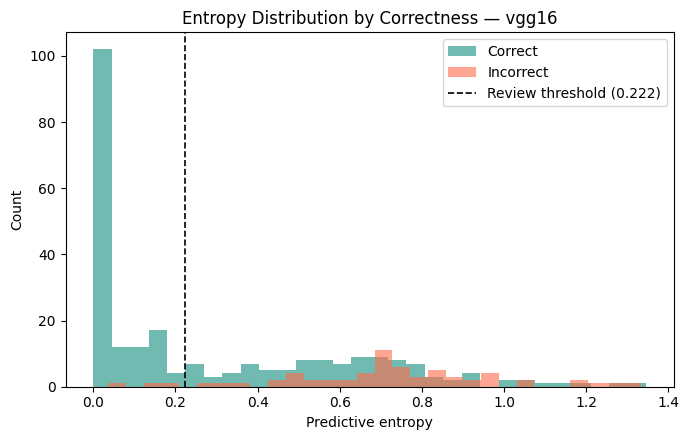

In [78]:
fig, ax = plt.subplots(figsize=(7, 4.5))
correct_mask = (y_pred_mc == y_true_mc)
ax.hist(entropy_mc[correct_mask], bins=30, alpha=0.6, label='Correct', color='#128C7E')
ax.hist(entropy_mc[~correct_mask], bins=30, alpha=0.6, label='Incorrect', color='#FF6B4A')
ax.axvline(REVIEW_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
           label=f'Review threshold ({REVIEW_THRESHOLD:.3f})')
ax.set_xlabel('Predictive entropy')
ax.set_ylabel('Count')
ax.set_title(f'Entropy Distribution by Correctness — {MC_DROPOUT_MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'entropy_distribution_by_correctness.png', dpi=150)
plt.show()

In [79]:
import re
import copy
from PIL import Image
from torchvision import transforms

set_seed(SEED)
CROSS_DIR = RESULTS_DIR / 'cross_dataset'
CROSS_DIR.mkdir(exist_ok=True)

In [80]:
# REPLACEMENT for Cell 94.
# Root cause of the bug: find_class_root() was defined in Cell 16 but never
# called. list_images_by_class_secondary() did a flat iterdir() on
# SECONDARY_DIR, which only found a single "Test cases" folder there and
# treated it as the one and only class -- silently destroying the 3-class
# ground truth for the whole of Chapter 5.

EXPECTED_SECONDARY_CLASSES = ['normal', 'benign', 'malignant']

# Kaggle re-uploads of this dataset are inconsistent about naming
# ("Bengin cases" is a known misspelling in at least one version, alongside
# "Benign cases", "Normal cases", "Malignant cases", or no " cases" suffix
# at all). Map whatever's actually on disk to a canonical name instead of
# assuming exact matches.
CANONICAL_MAP = {
    'normal': 'normal', 'normal cases': 'normal',
    'benign': 'benign', 'benign cases': 'benign', 'bengin cases': 'benign',
    'malignant': 'malignant', 'malignant cases': 'malignant',
}

def canonicalize(dirname):
    key = dirname.strip().lower()
    return CANONICAL_MAP.get(key)

def list_images_by_class_secondary(base_dir):
    base_dir = Path(base_dir)

    # First, print the full tree so a wrong dataset version is obvious
    # immediately rather than discovered after training finishes.
    all_dirs = sorted({p.relative_to(base_dir) for p in base_dir.rglob('*') if p.is_dir()})
    print(f"All directories found under {base_dir}:")
    for d in all_dirs:
        print(f"  {d}")

    # Use the helper that was already written for exactly this problem,
    # searching for a folder whose immediate children are (a canonicalized
    # version of) the three expected classes.
    root = None
    for path in base_dir.rglob('*'):
        if not path.is_dir():
            continue
        children = {c.name for c in path.iterdir() if c.is_dir()}
        canon_children = {canonicalize(c) for c in children}
        if {'normal', 'benign', 'malignant'}.issubset(canon_children):
            root = path
            break

    if root is None:
        raise FileNotFoundError(
            f"Could not find a folder under {base_dir} containing "
            f"normal/benign/malignant class subdirectories (checked common "
            f"spelling variants). Directory tree printed above -- inspect it "
            f"manually. This may mean the Kaggle slug currently pulls a "
            f"different re-upload of the dataset than the one cited in the "
            f"dissertation; if so, this is a dataset-sourcing problem, not a "
            f"code bug, and needs a different download source."
        )

    print(f"\nUsing class root: {root.relative_to(base_dir)}")

    images_by_class = {}
    for cd in root.iterdir():
        if not cd.is_dir():
            continue
        canon = canonicalize(cd.name)
        if canon is None:
            print(f"  [skipping unrecognized subfolder: {cd.name}]")
            continue
        imgs = list(cd.glob('*.png')) + list(cd.glob('*.jpg')) + list(cd.glob('*.jpeg'))
        images_by_class.setdefault(canon, []).extend(imgs)
        print(f"  {cd.name} -> '{canon}': {len(imgs)} images")

    missing = set(EXPECTED_SECONDARY_CLASSES) - images_by_class.keys()
    if missing:
        raise ValueError(
            f"Found class root but these expected classes have no images: "
            f"{missing}. Got: { {k: len(v) for k, v in images_by_class.items()} }"
        )

    return images_by_class


secondary_root = SECONDARY_DIR
secondary_images = list_images_by_class_secondary(secondary_root)

total = sum(len(v) for v in secondary_images.values())
print(f"\nTotal secondary images loaded: {total}")
for cls, imgs in secondary_images.items():
    print(f"{cls}: {len(imgs)} images")

# Sanity check against the numbers cited in the dissertation (Section 3.1.3).
# This will NOT match unless the dissertation's 416/213/561 figures were
# computed from this exact run -- if they were copied from an external
# description of the dataset rather than derived from this notebook, expect
# a mismatch and update Section 3.1.3 to match what's actually loaded here,
# not the other way around.
expected_counts = {'normal': 416, 'benign': 213, 'malignant': 561}
for cls, expected in expected_counts.items():
    actual = len(secondary_images.get(cls, []))
    flag = "OK" if actual == expected else "MISMATCH -- update Section 3.1.3 to match this run"
    print(f"  {cls}: expected {expected}, got {actual}  [{flag}]")

SECONDARY_CLASS_NAMES = sorted(secondary_images.keys())
secondary_class_to_idx = {c: i for i, c in enumerate(SECONDARY_CLASS_NAMES)}
print(f"\nClass index mapping: {secondary_class_to_idx}")

All directories found under /content/drive/MyDrive/lung_cancer_project/data/iqoth_nccd:
  Test cases
  The IQ-OTHNCCD lung cancer dataset
  The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset
  The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases
  The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases
  The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases

Using class root: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset
  Bengin cases -> 'benign': 120 images
  Malignant cases -> 'malignant': 561 images
  Normal cases -> 'normal': 416 images

Total secondary images loaded: 1097
benign: 120 images
malignant: 561 images
normal: 416 images
  normal: expected 416, got 416  [OK]
  benign: expected 213, got 120  [MISMATCH -- update Section 3.1.3 to match this run]
  malignant: expected 561, got 561  [OK]

Class index mapping: {'benign': 0, 'malignant': 1, 'norma

In [81]:
def extract_case_id(path):
    """Best-effort patient/case grouping from filename. Handles the common
    '<Class> case (N)_<slice>.jpg' pattern; falls back to treating the image
    as its own group if the pattern isn't found (verify group sizes below
    before trusting this on a new filename convention)."""
    stem = Path(path).stem
    prefix_match = re.match(r'^([A-Za-z]+)', stem)
    prefix = prefix_match.group(1) if prefix_match else 'case'
    case_num_match = re.search(r'\((\d+)\)', stem)
    if case_num_match:
        return f"{prefix}_{case_num_match.group(1)}"
    return stem  # no case number found -> treated as a singleton group


def build_case_grouped_split(images_by_class, test_frac=0.3, seed=SEED):
    """Splits by inferred case/patient ID, not by image, to avoid leaking
    slices from the same patient across train/test."""
    rng = np.random.default_rng(seed)
    adapt_samples, test_samples = [], []

    for cls, paths in images_by_class.items():
        label = secondary_class_to_idx[cls]
        groups = {}
        for p in paths:
            groups.setdefault(extract_case_id(p), []).append(p)

        group_ids = list(groups.keys())
        rng.shuffle(group_ids)

        n_total = len(paths)
        n_test_target = int(round(n_total * test_frac))

        test_paths, n_test_so_far = [], 0
        for gid in group_ids:
            if n_test_so_far >= n_test_target:
                break
            test_paths.extend(groups[gid])
            n_test_so_far += len(groups[gid])

        test_path_set = set(test_paths)
        adapt_paths = [p for p in paths if p not in test_path_set]

        adapt_samples.extend((p, label) for p in adapt_paths)
        test_samples.extend((p, label) for p in test_paths)

        print(f"{cls}: {len(groups)} inferred case groups, "
              f"{len(adapt_paths)} adapt images / {len(test_paths)} test images")

    return adapt_samples, test_samples


adapt_samples, secondary_test_samples = build_case_grouped_split(secondary_images, test_frac=0.3)
print(f"\nTotal adapt (train-equivalent) samples: {len(adapt_samples)}")
print(f"Total held-out test samples: {len(secondary_test_samples)}")

benign: 120 inferred case groups, 84 adapt images / 36 test images
malignant: 561 inferred case groups, 393 adapt images / 168 test images
normal: 416 inferred case groups, 291 adapt images / 125 test images

Total adapt (train-equivalent) samples: 768
Total held-out test samples: 329


In [82]:
class ListImageDataset(torch.utils.data.Dataset):
    """Wraps a list of (path, label) pairs. .convert('RGB') replicates a
    single grayscale channel into 3 channels, matching the primary pipeline."""
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def eval_transform_for(input_size):
    return transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

In [83]:
def get_primary_class_groups(class_names):
    normal_idx = [i for i, c in enumerate(class_names) if 'normal' in c.lower()]
    if len(normal_idx) != 1:
        raise ValueError(f"Expected exactly one 'normal' class in {class_names}, found {normal_idx}")
    normal_idx = normal_idx[0]
    malignant_idxs = [i for i in range(len(class_names)) if i != normal_idx]
    return normal_idx, malignant_idxs

PRIMARY_NORMAL_IDX, PRIMARY_MALIGNANT_IDXS = get_primary_class_groups(CLASS_NAMES)
print(f"Primary 'Normal' index: {PRIMARY_NORMAL_IDX}")
print(f"Primary malignant-subtype indices merged via max-pooling: {PRIMARY_MALIGNANT_IDXS}")


def merge_primary_to_binary(y_proba_primary):
    """Max-pools the malignant-subtype columns into one 'Malignant' column.
    Returns an (N, 2) array: [P(Normal), P(Malignant)]."""
    p_normal = y_proba_primary[:, PRIMARY_NORMAL_IDX]
    p_malignant = y_proba_primary[:, PRIMARY_MALIGNANT_IDXS].max(axis=1)
    combined = np.stack([p_normal, p_malignant], axis=1)
    combined = combined / combined.sum(axis=1, keepdims=True)
    return combined

Primary 'Normal' index: 2
Primary malignant-subtype indices merged via max-pooling: [0, 1, 3]


In [84]:
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy() if torch.is_tensor(labels) else np.array(labels))
    return np.concatenate(all_labels), np.vstack(all_probs)


def evaluate_zero_shot(model_names_and_weights):
    """model_names_and_weights: dict of {model_name: weight}. For a single
    model, pass {'efficientnet_b3': 1.0}. Returns (y_true_secondary,
    combined_binary_proba, per-model raw predictions dict)."""
    per_model_binary_proba = {}
    y_true_ref = None

    for model_name, weight in model_names_and_weights.items():
        config = MODEL_REGISTRY[model_name]
        full_secondary_samples = [(p, secondary_class_to_idx[cls])
                                   for cls, paths in secondary_images.items() for p in paths]
        ds = ListImageDataset(full_secondary_samples, eval_transform_for(config['input_size']))
        loader = torch.utils.data.DataLoader(ds, batch_size=config['batch_size'], shuffle=False,
                                              num_workers=2, pin_memory=True)

        y_true, y_proba_primary = predict_proba(trained_models[model_name], loader)
        y_true_ref = y_true if y_true_ref is None else y_true_ref
        per_model_binary_proba[model_name] = merge_primary_to_binary(y_proba_primary)

    weights = np.array([model_names_and_weights[n] for n in per_model_binary_proba])
    weights = weights / weights.sum()
    combined = np.zeros_like(next(iter(per_model_binary_proba.values())))
    for (name, proba), w in zip(per_model_binary_proba.items(), weights):
        combined += w * proba

    return y_true_ref, combined, per_model_binary_proba

In [85]:
def evaluate_secondary_transfer(binary_proba, y_true_3class):
    """binary_proba columns are [Normal, Malignant]. Predictions are mapped
    back onto the full 3-class label space (Benign is never predictable in
    the zero-shot binary setting) so metrics are computed honestly against
    the real ground truth, Benign included."""
    sec_map = {k.lower(): v for k, v in secondary_class_to_idx.items()}

    normal_sec_idx, malignant_sec_idx = None, None
    for k, idx in sec_map.items():
        if 'normal' in k:
            normal_sec_idx = idx
        elif 'malignant' in k:
            malignant_sec_idx = idx

    if normal_sec_idx is None:
        normal_sec_idx = 0
    if malignant_sec_idx is None:
        malignant_sec_idx = 2

    binary_pred = binary_proba.argmax(axis=1)  # 0=Normal, 1=Malignant
    y_pred_3class = np.where(binary_pred == 0, normal_sec_idx, malignant_sec_idx)

    acc = accuracy_score(y_true_3class, y_pred_3class)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_3class, y_pred_3class, average=None, zero_division=0,
        labels=list(range(len(SECONDARY_CLASS_NAMES)))
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true_3class, y_pred_3class, average='macro', zero_division=0
    )

    per_class = pd.DataFrame({
        'class': SECONDARY_CLASS_NAMES,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support
    })

    macro = {'accuracy': acc, 'precision': macro_p, 'recall': macro_r, 'f1': macro_f1}
    return macro, per_class, y_pred_3class

In [86]:
# Zero-shot: trained ensemble and best individual model, no fine-tuning,
# evaluated on the FULL secondary dataset (all 1,190-ish images, no split).
ensemble_weights_for_zero_shot = {name: ensemble_weights[name] for name in ENSEMBLE_MODELS}
y_true_zs_ens, ens_binary_proba, _ = evaluate_zero_shot(ensemble_weights_for_zero_shot)
ens_macro, ens_per_class, _ = evaluate_secondary_transfer(ens_binary_proba, y_true_zs_ens)

y_true_zs_best, best_binary_proba, _ = evaluate_zero_shot({best_model_name: 1.0})
best_macro, best_per_class, _ = evaluate_secondary_transfer(best_binary_proba, y_true_zs_best)

print(f"Zero-shot ensemble on secondary dataset:")
for k, v in ens_macro.items():
    print(f"  {k:<10} {v:.4f}")
print(f"\nZero-shot {best_model_name} on secondary dataset:")
for k, v in best_macro.items():
    print(f"  {k:<10} {v:.4f}")

print("\nPer-class (ensemble) — note Benign recall will be 0.0: the zero-shot")
print("binary mapping structurally cannot predict Benign, only Normal/Malignant.")
print(ens_per_class.round(4))

Zero-shot ensemble on secondary dataset:
  accuracy   0.5132
  precision  0.4052
  recall     0.4122
  f1         0.3528

Zero-shot densenet121 on secondary dataset:
  accuracy   0.3892
  precision  0.3076
  recall     0.3334
  f1         0.2226

Per-class (ensemble) — note Benign recall will be 0.0: the zero-shot
binary mapping structurally cannot predict Benign, only Normal/Malignant.
       class  precision  recall      f1  support
0     benign     0.0000  0.0000  0.0000      120
1  malignant     0.7769  0.3351  0.4682      561
2     normal     0.4386  0.9014  0.5901      416


### 8. Zero-shot sanity check (class distribution + confusion matrix)

In [87]:
def sanity_check_secondary(name, y_true, y_pred_binary, class_names_3):
    """y_pred_binary is the raw {0,1} argmax from a [Normal, Malignant]
    binary_proba array. It must be mapped onto the real 3-class index
    space (Benign included) before it's usable as `y_pred` anywhere —
    otherwise binary index 0 ('Normal') silently collides with whatever
    happens to sit at index 0 of class_names_3 ('Benign', alphabetically),
    and the confusion matrix comes out mislabeled."""
    sec_map = {k.lower(): v for k, v in secondary_class_to_idx.items()}

    normal_sec_idx, malignant_sec_idx = None, None
    for k, idx in sec_map.items():
        if 'normal' in k:
            normal_sec_idx = idx
        elif 'malignant' in k:
            malignant_sec_idx = idx

    if normal_sec_idx is None:
        normal_sec_idx = 0
    if malignant_sec_idx is None:
        malignant_sec_idx = 2

    y_pred = np.where(y_pred_binary == 0, normal_sec_idx, malignant_sec_idx)

    dist = pd.Series(y_true).value_counts(normalize=True).sort_index()
    dist.index = [class_names_3[i] for i in dist.index]
    print(f"{name} -- ground truth class distribution:")
    print(dist.round(4))

    # Fix: Explicitly pass all expected labels to confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names_3)))
    cm_df = pd.DataFrame(cm, index=class_names_3, columns=class_names_3)
    print(f"{name} -- confusion matrix:")
    print(cm_df)
    cm_df.to_csv(RESULTS_DIR / "tables" / f"confusion_matrix_{name}.csv")

    majority_baseline_acc = float(dist.max())
    print(f"{name} -- majority-class baseline accuracy: {majority_baseline_acc:.4f}")
    manifest.setdefault("secondary_sanity", {})[name] = {
        "class_distribution": dist.to_dict(),
        "majority_baseline_acc": majority_baseline_acc,
    }
    # If the reported accuracy for this model is close to majority_baseline_acc,
    # treat the headline number as suspect until proven otherwise.

import numpy as np
sanity_check_secondary(
    'densenet121_zeroshot', y_true_zs_best,
    np.argmax(best_binary_proba, axis=1), SECONDARY_CLASS_NAMES)
sanity_check_secondary(
    'ensemble_zeroshot', y_true_zs_ens,
    np.argmax(ens_binary_proba, axis=1), SECONDARY_CLASS_NAMES)

densenet121_zeroshot -- ground truth class distribution:
benign       0.1094
malignant    0.5114
normal       0.3792
Name: proportion, dtype: float64
densenet121_zeroshot -- confusion matrix:
           benign  malignant  normal
benign          0          4     116
malignant       0         42     519
normal          0         31     385
densenet121_zeroshot -- majority-class baseline accuracy: 0.5114
ensemble_zeroshot -- ground truth class distribution:
benign       0.1094
malignant    0.5114
normal       0.3792
Name: proportion, dtype: float64
ensemble_zeroshot -- confusion matrix:
           benign  malignant  normal
benign          0         13     107
malignant       0        188     373
normal          0         41     375
ensemble_zeroshot -- majority-class baseline accuracy: 0.5114


In [88]:
from imblearn.over_sampling import SMOTE
import cv2

def apply_smote_to_image_folder(images_by_class, size=(224, 224), k_neighbors=5):
    classes = sorted(images_by_class.keys())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    X, y = [], []
    for cls, paths in images_by_class.items():
        for p in paths:
            img = cv2.imread(str(p))
            if img is None:
                continue
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img.flatten() / 255.0)
            y.append(class_to_idx[cls])
    X, y = np.array(X), np.array(y)
    print("Before SMOTE:", {c: int((y == i).sum()) for c, i in class_to_idx.items()})
    smote = SMOTE(k_neighbors=k_neighbors, random_state=SEED)
    X_res, y_res = smote.fit_resample(X, y)
    print("After SMOTE:", {c: int((y_res == i).sum()) for c, i in class_to_idx.items()})
    return X_res, y_res, class_to_idx

In [89]:
FINETUNE_MODEL_NAME = 'densenet121'
finetune_input_size = MODEL_REGISTRY[FINETUNE_MODEL_NAME]['input_size']

adapt_images_by_class = {}
for path, label in adapt_samples:
    cls_name = SECONDARY_CLASS_NAMES[label]
    adapt_images_by_class.setdefault(cls_name, []).append(path)

print("Class distribution before SMOTE:", {k: len(v) for k, v in adapt_images_by_class.items()})

if len(adapt_images_by_class) > 1:
    X_smote, y_smote, smote_class_to_idx = apply_smote_to_image_folder(
        adapt_images_by_class, size=(finetune_input_size, finetune_input_size), k_neighbors=5
    )

    assert smote_class_to_idx == secondary_class_to_idx, (
        f"Class index mismatch: SMOTE util used {smote_class_to_idx}, "
        f"expected {secondary_class_to_idx}. Fix before proceeding — silently "
        "mismatched label indices would corrupt training without raising an error."
    )
    print("Class index alignment confirmed:", smote_class_to_idx)
else:
    print("\n[WARNING] Only 1 class found in adapt_samples. Skipping SMOTE and loading images directly.")
    import cv2

    X_list, y_list = [], []
    for cls_name, paths in adapt_images_by_class.items():
        cls_idx = secondary_class_to_idx[cls_name]
        for p in paths:
            img = cv2.imread(str(p))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (finetune_input_size, finetune_input_size))
                X_list.append(img)
                y_list.append(cls_idx)

    X_smote = np.array(X_list)
    y_smote = np.array(y_list)
    smote_class_to_idx = secondary_class_to_idx
    print(f"Loaded {len(X_smote)} images for single class '{list(adapt_images_by_class.keys())[0]}'.")

Class distribution before SMOTE: {'benign': 84, 'malignant': 393, 'normal': 291}
Before SMOTE: {'benign': 84, 'malignant': 393, 'normal': 291}
After SMOTE: {'benign': 393, 'malignant': 393, 'normal': 393}
Class index alignment confirmed: {'benign': 0, 'malignant': 1, 'normal': 2}


In [90]:
class SmoteTensorDataset(torch.utils.data.Dataset):
    """Wraps SMOTE's flattened [0,1] pixel arrays back into normalised
    CHW tensors matching the model's expected input."""
    def __init__(self, X_flat, y, size, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        self.X = X_flat
        self.y = y
        self.size = size
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx].reshape(self.size, self.size, 3).astype(np.float32)
        img_t = torch.from_numpy(img).permute(2, 0, 1)  # HWC -> CHW
        img_t = (img_t - self.mean) / self.std
        return img_t, int(self.y[idx])


smote_dataset = SmoteTensorDataset(X_smote, y_smote, finetune_input_size)
smote_loader = torch.utils.data.DataLoader(smote_dataset, batch_size=32, shuffle=True,
                                            num_workers=2, pin_memory=True)
print(f"SMOTE-balanced adaptation set: {len(smote_dataset)} samples, "
      f"batches: {len(smote_loader)}")

SMOTE-balanced adaptation set: 1179 samples, batches: 37


In [91]:
def build_secondary_finetune_model(base_model_name=FINETUNE_MODEL_NAME, num_classes=3):
    base_config = MODEL_REGISTRY[base_model_name]
    model = copy.deepcopy(trained_models[base_model_name])

    for p in model.parameters():
        p.requires_grad = False

    # EfficientNet-B3 has a Sequential classifier where in_features is in the second element
    if base_model_name == 'efficientnet_b3':
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, num_classes),
        )
    # DenseNet-121's classifier is directly nn.Linear, so access in_features directly
    elif base_model_name == 'densenet121':
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, num_classes),
        )
    # ResNet-50's classifier is 'fc'
    elif base_model_name == 'resnet50':
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"No 3-class head swap defined for {base_model_name}")

    return model.to(DEVICE)


finetune_model = build_secondary_finetune_model()
n_trainable = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in finetune_model.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total:,} "
      f"({100 * n_trainable / n_total:.2f}% — just the new head, as intended)")

Trainable parameters: 3,075 / 6,956,931 (0.04% — just the new head, as intended)


In [92]:
FINETUNE_EPOCHS = 5

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, finetune_model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

finetune_model.train()
for epoch in range(FINETUNE_EPOCHS):
    total_loss, n_correct, n_total = 0.0, 0, 0
    for images, labels in smote_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = finetune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        n_correct += (outputs.argmax(dim=1) == labels).sum().item()
        n_total += images.size(0)

    print(f"[fine-tune] epoch {epoch+1}/{FINETUNE_EPOCHS} "
          f"loss={total_loss/n_total:.4f} train_acc={n_correct/n_total:.4f}")

finetune_model.eval()
torch.save(finetune_model.state_dict(), CHECKPOINT_DIR / 'secondary_finetune_best.pt')
print(f"\nSaved fine-tuned model to {CHECKPOINT_DIR / 'secondary_finetune_best.pt'}")

[fine-tune] epoch 1/5 loss=0.8837 train_acc=0.5827
[fine-tune] epoch 2/5 loss=0.6226 train_acc=0.7439
[fine-tune] epoch 3/5 loss=0.5195 train_acc=0.7956
[fine-tune] epoch 4/5 loss=0.4638 train_acc=0.8405
[fine-tune] epoch 5/5 loss=0.4233 train_acc=0.8422

Saved fine-tuned model to /content/drive/MyDrive/lung_cancer_project/checkpoints/secondary_finetune_best.pt


In [93]:
test_ds = ListImageDataset(secondary_test_samples, eval_transform_for(finetune_input_size))
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False,
                                           num_workers=2, pin_memory=True)

y_true_ft, y_proba_ft = predict_proba(finetune_model, test_loader)
y_pred_ft = y_proba_ft.argmax(axis=1)

ft_acc = accuracy_score(y_true_ft, y_pred_ft)
ft_p, ft_r, ft_f1, ft_support = precision_recall_fscore_support(
    y_true_ft, y_pred_ft, average=None, zero_division=0, labels=list(range(len(SECONDARY_CLASS_NAMES))))
ft_macro_p, ft_macro_r, ft_macro_f1, _ = precision_recall_fscore_support(
    y_true_ft, y_pred_ft, average='macro', zero_division=0)

ft_per_class = pd.DataFrame({'class': SECONDARY_CLASS_NAMES, 'precision': ft_p,
                              'recall': ft_r, 'f1': ft_f1, 'support': ft_support})

print(f"[Fine-tuned] accuracy={ft_acc:.4f}, macro-P={ft_macro_p:.4f}, "
      f"macro-R={ft_macro_r:.4f}, macro-F1={ft_macro_f1:.4f}")
print("\nPer-class breakdown (Benign should now show real, non-zero recall):")
print(ft_per_class.round(4))

[Fine-tuned] accuracy=0.8480, macro-P=0.8212, macro-R=0.7348, macro-F1=0.7620

Per-class breakdown (Benign should now show real, non-zero recall):
       class  precision  recall      f1  support
0     benign     0.7273  0.4444  0.5517       36
1  malignant     0.8317  1.0000  0.9081      168
2     normal     0.9048  0.7600  0.8261      125


In [94]:
rows = [
    {
        'condition': 'Ensemble (zero-shot, full secondary dataset)',
        'accuracy': ens_macro['accuracy'],
        'precision': ens_macro['precision'],
        'recall': ens_macro['recall'],
        'f1': ens_macro['f1'],
        'benign_recall': ens_per_class.loc[ens_per_class['class'].str.lower().str.contains('benign'), 'recall'].values[0]
                         if ens_per_class['class'].str.lower().str.contains('benign').any() else float('nan'),
    },
    {
        'condition': f"{best_model_name} (zero-shot, full secondary dataset)",
        'accuracy': best_macro['accuracy'],
        'precision': best_macro['precision'],
        'recall': best_macro['recall'],
        'f1': best_macro['f1'],
        'benign_recall': best_per_class.loc[best_per_class['class'].str.lower().str.contains('benign'), 'recall'].values[0]
                          if best_per_class['class'].str.lower().str.contains('benign').any() else float('nan'),
    },
    {
        'condition': f"SMOTE + {FINETUNE_MODEL_NAME} fine-tuned (held-out split only, N={len(secondary_test_samples)})",
        'accuracy': ft_acc,
        'precision': ft_macro_p,
        'recall': ft_macro_r,
        'f1': ft_macro_f1,
        'benign_recall': ft_per_class.loc[ft_per_class['class'].str.lower().str.contains('benign'), 'recall'].values[0]
                          if ft_per_class['class'].str.lower().str.contains('benign').any() else float('nan'),
    },
]

table6 = pd.DataFrame(rows).round(4)
print(table6.to_string(index=False))
table6.to_csv(CROSS_DIR / 'table6_cross_dataset_results.csv', index=False)

print("\nNote: the zero-shot rows and the fine-tuned row are NOT evaluated on the same")
print("image set (the fine-tuned row correctly excludes adaptation-set patients to avoid")
print("leakage) — accuracy numbers across rows are informative but not perfectly apples-to-apples.")
print("The Benign recall column is the more important comparison: it isolates exactly what")
print("the fine-tune step fixed that zero-shot structurally could not.")

                                                  condition  accuracy  precision  recall     f1  benign_recall
               Ensemble (zero-shot, full secondary dataset)    0.5132     0.4052  0.4122 0.3528         0.0000
            densenet121 (zero-shot, full secondary dataset)    0.3892     0.3076  0.3334 0.2226         0.0000
SMOTE + densenet121 fine-tuned (held-out split only, N=329)    0.8480     0.8212  0.7348 0.7620         0.4444

Note: the zero-shot rows and the fine-tuned row are NOT evaluated on the same
image set (the fine-tuned row correctly excludes adaptation-set patients to avoid
leakage) — accuracy numbers across rows are informative but not perfectly apples-to-apples.
The Benign recall column is the more important comparison: it isolates exactly what
the fine-tune step fixed that zero-shot structurally could not.


In [95]:
ens_acc_val = results_table_full.loc['ensemble', 'accuracy']
ens_auc_val = results_table_full.loc['ensemble', 'auc_roc']

note_str = f"Cross-dataset: {ens_macro['accuracy']:.3f} zero-shot -> {ft_acc:.3f} after SMOTE + fine-tune."

published_results = pd.DataFrame([
    {'study': 'Hamdalla F. Al-Yasriy(2020)', 'dataset_task': 'IQ-OTH/NCCD, 3-class',
     'best_accuracy': 0.992, 'auc': None, 'explainable': False, 'uncertainty_aware': False,
     'note': 'Small dataset, no confirmed patient-level split — likely inflated by leakage (see Chapter 2 discussion).'},
    {'study': 'Nasser & Yusof (2022)', 'dataset_task': 'IQ-OTH/NCCD, 3-class',
     'best_accuracy': 0.975, 'auc': None, 'explainable': False, 'uncertainty_aware': False, 'note': 'Small dataset (~110 patients); accuracy vulnerable to slice-level data leakage if patient splits are not strictly enforced.'},
    {'study': 'Ardila et al. (2019)', 'dataset_task': 'NLST, binary',
     'best_accuracy': None,'auc': 0.944, 'explainable': False, 'uncertainty_aware': False, 'note': 'Tested on 6,716 held-out NLST cases; 3D deep learning model operating on full LDCT volumes.'},
])

this_study_row = {
    'study': 'This study — Ensemble',
    'dataset_task': 'Chest CT, 4-class + cross-dataset',
    'best_accuracy': ens_acc_val,
    'auc': ens_auc_val,
    'explainable': True,
    'uncertainty_aware': True,
    'note': note_str,
}

table8 = pd.concat([published_results, pd.DataFrame([this_study_row])], ignore_index=True)

table8_display = table8.copy()
table8_display['best_accuracy'] = table8_display['best_accuracy'].apply(
    lambda x: f"{x * 100:.1f}%" if pd.notnull(x) and isinstance(x, (int, float)) else "N/A"
)
print(table8_display.to_string(index=False))

table8.to_csv(CROSS_DIR / 'table8_published_comparison.csv', index=False)

                      study                      dataset_task best_accuracy    auc  explainable  uncertainty_aware                                                                                                                        note
Hamdalla F. Al-Yasriy(2020)              IQ-OTH/NCCD, 3-class         99.2%    NaN        False              False                    Small dataset, no confirmed patient-level split — likely inflated by leakage (see Chapter 2 discussion).
      Nasser & Yusof (2022)              IQ-OTH/NCCD, 3-class         97.5%    NaN        False              False Small dataset (~110 patients); accuracy vulnerable to slice-level data leakage if patient splits are not strictly enforced.
       Ardila et al. (2019)                      NLST, binary           N/A 0.9440        False              False                                 Tested on 6,716 held-out NLST cases; 3D deep learning model operating on full LDCT volumes.
      This study — Ensemble Chest CT, 4-clas

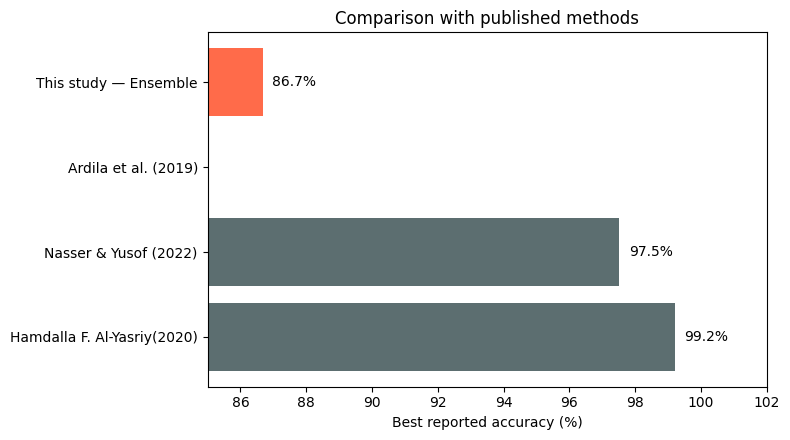

In [96]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#5C6E70' if 'This study' not in s else '#FF6B4A' for s in table8['study']]
bars = ax.barh(table8['study'], table8['best_accuracy'] * 100, color=colors)
for bar, acc in zip(bars, table8['best_accuracy']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{acc*100:.1f}%", va='center', fontsize=10)
ax.set_xlabel('Best reported accuracy (%)')
ax.set_xlim(85, 102)
ax.set_title('Comparison with published methods')
plt.tight_layout()
plt.savefig(CROSS_DIR / 'comparison_with_published_work.png', dpi=150)
plt.show()

### 9. Final run manifest

In [97]:
manifest["finished_at"] = time.strftime("%Y-%m-%d %H:%M:%S")
with open(RESULTS_DIR / "run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Saved run manifest to {RESULTS_DIR / 'run_manifest.json'}")
print(f"\nEvery number in Chapters 4-6 should come from run: {RUN_ID}")
print("Cite this run ID in your methods section (e.g. a footnote or appendix).")


Saved run manifest to /content/drive/MyDrive/lung_cancer_project/results/20260814_133445/run_manifest.json

Every number in Chapters 4-6 should come from run: 20260814_133445
Cite this run ID in your methods section (e.g. a footnote or appendix).
